# DATA OVERVIEW

## 1. Tổng quan về dataset

### 1.1. Nguồn và nội dung dữ liệu

**European Soccer Database** là bộ dữ liệu lịch sử về bóng đá chuyên nghiệp châu Âu, được **Hugo Mathien** tổng hợp và công bố trên Kaggle dưới dạng file SQLite `database.sqlite`.

Theo mô tả của tác giả, dataset bao gồm:

* hơn 25.000 trận đấu;
* hơn 10.000 cầu thủ;
* 11 quốc gia châu Âu cùng các giải vô địch quốc gia chính;
* các mùa giải từ 2008 đến 2016;
* `player attributes` và `team attributes` từ dòng game EA Sports FIFA;
* đội hình thi đấu và vị trí cầu thủ dưới dạng tọa độ X, Y;
* `betting odds` từ tối đa 10 providers;
* các `match events` như bàn thắng, kiểm soát bóng, phạt góc, tạt bóng, phạm lỗi và thẻ phạt cho hơn 10.000 trận đấu.

Dataset có cấu trúc `relational database`, trong đó dữ liệu được tổ chức thành nhiều bảng liên quan đến quốc gia, giải đấu, trận đấu, đội bóng, cầu thủ và các thuộc tính theo thời gian.

### 1.2. Nguồn thu thập dữ liệu

Dữ liệu được tổng hợp từ nhiều nguồn bóng đá khác nhau:

| Nguồn                                 | Nội dung được thu thập                                              |
| ------------------------------------- | ------------------------------------------------------------------- |
| `football-data.mx-api.enetscores.com` | Kết quả trận đấu, đội hình, sơ đồ thi đấu và các sự kiện trong trận |
| `football-data.co.uk`                 | Betting odds từ nhiều providers                                     |
| `sofifa.com`                          | Player attributes và team attributes từ EA Sports FIFA              |

Các identifier được lấy từ nguồn ban đầu được tác giả giữ lại trong database và đặt tên với hậu tố `api_id`, chẳng hạn như `team_api_id`, `player_api_id` và `match_api_id`. Những trường này được sử dụng để liên kết dữ liệu giữa các bảng.

### 1.3. Phương pháp thu thập và xử lý

Tác giả xây dựng các công cụ `web crawling` bằng Python và framework Scrapy. Hai crawler chính gồm:

* `MatchSpider`: thu thập thông tin trận đấu, kết quả, match statistics, team line-up và match events;
* `PlayerSpider`: tìm kiếm và thu thập các thuộc tính cầu thủ từ SoFIFA.

Quy trình thu thập được mô tả khái quát như sau:

1. Thu thập dữ liệu trận đấu và đội hình.
2. Trích xuất danh sách cầu thủ xuất hiện trong các trận đấu.
3. Chuẩn hóa và loại bỏ tên cầu thủ trùng lặp.
4. Tìm kiếm cầu thủ tương ứng trên SoFIFA.
5. Thu thập các thuộc tính FIFA theo từng thời điểm.
6. Kết hợp và lưu trữ dữ liệu thành các bảng trong SQLite database.

Do dữ liệu được tổng hợp từ nhiều nguồn, quá trình `entity matching` có thể gặp khó khăn khi tên cầu thủ không đồng nhất. Một số cầu thủ vì vậy có thể không được tìm thấy trong dữ liệu FIFA, dẫn đến giá trị `NULL` tại các cột đội hình hoặc thuộc tính liên quan.

Ngoài ra, tác giả lưu ý rằng giao diện SoFIFA đã thay đổi sau khi các crawler ban đầu được xây dựng, vì vậy phiên bản `PlayerSpider` trong repository có thể không còn hoạt động nếu chưa được cập nhật.

### 1.4. License và phạm vi sử dụng

Dataset được công bố theo **Open Database License – ODbL 1.0**.

Thông tin license được thể hiện như sau:

* **Database:** Open Database;
* **Contents:** © Original Authors.

ODbL cho phép người dùng sử dụng, chia sẻ và điều chỉnh database với các điều kiện chính như:

* ghi nhận nguồn dữ liệu – `Attribution`;
* tiếp tục chia sẻ `Derivative Database` theo cùng license – `Share-Alike`;
* duy trì quyền truy cập mở đối với database khi được phân phối công khai.

License của database không tự động thay thế quyền sở hữu đối với từng nội dung gốc bên trong. Các dữ liệu có nguồn từ EA Sports FIFA và những providers khác vẫn thuộc quyền của các tác giả hoặc chủ sở hữu ban đầu.

Tác giả dataset cũng đề nghị không sử dụng dữ liệu cho mục đích thương mại. Trong đồ án này, dataset chỉ được sử dụng cho mục đích học tập, phân tích dữ liệu và trực quan hóa bằng Power BI. Nguồn Kaggle, repository thu thập dữ liệu và license ODbL sẽ được ghi nhận trong phần tài liệu tham khảo.


## 2. Kết nối và đọc dữ liệu SQLite

Dataset được lưu trong file `database.sqlite`. Phần này sử dụng thư viện `sqlite3` để kết nối cơ sở dữ liệu ở chế độ `read-only` và thực hiện một truy vấn đơn giản nhằm xác nhận notebook có thể đọc dữ liệu thành công.

In [2]:
import sqlite3
import pandas as pd

from pathlib import Path

In [ ]:
DATABASE_PATH = Path("../data/raw/database.sqlite").resolve()

database_uri = f"file:{DATABASE_PATH.as_posix()}?mode=ro" # read-only mode

connection = sqlite3.connect(
    database_uri,
    uri=True,
)

print("Kết nối database thành công.")

Kết nối database thành công.


In [5]:
connection_test = pd.read_sql_query(
    """
    SELECT COUNT(*) AS table_count
    FROM sqlite_master
    WHERE type = 'table'
      AND name NOT LIKE 'sqlite_%';
    """,
    connection,
)

connection_test

,table_count
0,7


**Kết quả**

Notebook đã kết nối thành công với file `database.sqlite` ở chế độ `read-only` và có thể thực hiện truy vấn SQL trên cơ sở dữ liệu.

## 3. Liệt kê các bảng trong database

SQLite lưu thông tin về các đối tượng trong database tại bảng metadata `sqlite_master`.

Phần này truy vấn `sqlite_master` để lấy danh sách các bảng nghiệp vụ hiện có trong file `database.sqlite`, đồng thời loại bỏ các bảng hệ thống do SQLite tự tạo.

In [6]:
tables_query = """
    SELECT name as table_name
    FROM sqlite_master
    WHERE type='table'
        AND name NOT LIKE 'sqlite_%'
    ORDER BY name;
"""

In [7]:
tables = pd.read_sql_query(tables_query, connection)

print("Danh sách các bảng trong cơ sở dữ liệu:")
tables

Danh sách các bảng trong cơ sở dữ liệu:


,table_name
0,Country
1,League
2,Match
3,Player
4,Player_Attributes
5,Team
6,Team_Attributes


**Nhận xét**

Database gồm 7 bảng nghiệp vụ:

- `Country`;
- `League`;
- `Match`;
- `Player`;
- `Player_Attributes`;
- `Team`;
- `Team_Attributes`.

Các bảng thể hiện nhiều nhóm thực thể và sự kiện khác nhau, cho thấy European Soccer Database được tổ chức theo mô hình dữ liệu quan hệ thay vì lưu toàn bộ thông tin trong một bảng duy nhất.

Trong đó, `Match` dự kiến là bảng dữ liệu trung tâm, còn `Country`, `League`, `Team` và `Player` đóng vai trò lưu thông tin mô tả. Hai bảng `Team_Attributes` và `Player_Attributes` lưu các thuộc tính được ghi nhận theo thời gian.

## 4. Thống kê quy mô các bảng

Phần này thống kê số dòng và số cột của từng bảng nhằm đánh giá quy mô dữ liệu, nhận diện các bảng lớn và chuẩn bị cho việc khảo sát schema ở các phần tiếp theo.

Trong đó:

- `row_count` thể hiện số bản ghi của bảng;
- `column_count` thể hiện số thuộc tính được lưu trong bảng.

Kết quả này chỉ phản ánh quy mô dữ liệu, chưa đánh giá chất lượng như missing values, duplicate hoặc outlier.

In [8]:
def quote_identifier(identifier: str) -> str:
    return '"' + identifier.replace('"', '""') + '"'

In [9]:
table_size_records = []

for table_name in tables["table_name"]:
    quoted_table = quote_identifier(table_name)
    
    row_count_query = f"""
        SELECT COUNT(*) AS row_count
        FROM {quoted_table};
        """
    
    row_count = pd.read_sql_query(row_count_query, connection).iloc[0]["row_count"]

    table_schema = pd.read_sql_query(f"PRAGMA table_info({quoted_table});", connection)

    count_columns = len(table_schema)

    table_size_records.append({
        "table_name": table_name,
        "row_count": row_count,
        "column_count": count_columns,
    })

In [10]:
table_size = pd.DataFrame(table_size_records)

table_size = table_size.sort_values(by="row_count", ascending=False).reset_index(drop=True)

display(table_size)

,table_name,row_count,column_count
0,Player_Attributes,183978,42
1,Match,25979,115
2,Player,11060,7
3,Team_Attributes,1458,25
4,Team,299,5
5,League,11,3
6,Country,11,2


**Nhận xét**

Database gồm 7 bảng với quy mô khác nhau:

* `Player_Attributes` là bảng có nhiều dòng nhất, với **183.978 bản ghi và 42 cột**. Bảng này lưu nhiều lần cập nhật thuộc tính cho cùng một cầu thủ theo thời gian, vì vậy số dòng lớn hơn nhiều so với số cầu thủ thực tế.
* `Match` gồm **25.979 bản ghi và 115 cột**. Mỗi dòng dự kiến đại diện cho một trận đấu. Đây là bảng có nhiều cột nhất do ngoài thông tin kết quả còn chứa đội hình, vị trí cầu thủ, match events và betting odds.
* `Player` gồm **11.060 dòng và 7 cột**, tương ứng với danh mục thông tin cơ bản của các cầu thủ.
* `Team_Attributes` gồm **1.458 dòng và 25 cột**. Số dòng lớn hơn số đội cho thấy một đội có thể có nhiều bản ghi thuộc tính tại các thời điểm khác nhau.
* `Team` gồm **299 dòng và 5 cột**, lưu thông tin định danh của các đội bóng.
* `Country` và `League` đều có **11 dòng**, lần lượt lưu danh sách quốc gia và giải đấu được bao phủ trong dataset.

Nhìn chung, các bảng nhỏ như `Country`, `League`, `Team` và `Player` chủ yếu đóng vai trò bảng mô tả hoặc `dimension`. Các bảng `Match`, `Team_Attributes` và `Player_Attributes` lưu dữ liệu sự kiện hoặc dữ liệu thay đổi theo thời gian.


## 5. Khảo sát schema và dữ liệu mẫu

Phần này khảo sát cấu trúc của từng bảng thông qua `schema` và một số bản ghi mẫu.

Trong đó:

* `schema` cho biết tên cột, kiểu dữ liệu và các constraint được khai báo;
* dữ liệu mẫu giúp quan sát cách các giá trị được lưu trữ trong thực tế.

In [ ]:
# Thu thập schema của tất cả bảng

schema_records = []

for table_name in tables["table_name"]:
    quoted_table = quote_identifier(table_name)
    
    table_schema = pd.read_sql_query(f"PRAGMA table_info({quoted_table});", connection)

    table_schema.insert(0, "table_name", table_name)

    schema_records.append(table_schema)

database_schema = pd.concat(schema_records, ignore_index=True)

database_schema = database_schema.rename(
    columns={
        "name": "column_name",
        "type": "data_type",
        "notnull": "not_null",
        "dflt_value": "default_value",
        "pk": "primary_key",
    }
)

display(database_schema)

,table_name,cid,column_name,data_type,not_null,default_value,primary_key
0,Country,0,id,INTEGER,0,None,1
1,Country,1,name,TEXT,0,None,0
2,League,0,id,INTEGER,0,None,1
3,League,1,country_id,INTEGER,0,None,0
4,League,2,name,TEXT,0,None,0
...,...,...,...,...,...,...,...
194,Team_Attributes,20,defenceAggression,INTEGER,0,None,0
195,Team_Attributes,21,defenceAggressionClass,TEXT,0,None,0
196,Team_Attributes,22,defenceTeamWidth,INTEGER,0,None,0
197,Team_Attributes,23,defenceTeamWidthClass,TEXT,0,None,0


In [12]:
# Hiển thị schema riêng từng bảng

for table_name in tables["table_name"]:

    print(f"Schema của bảng '{table_name}':")

    table_schema_view = database_schema.loc[
        database_schema["table_name"] == table_name,
        [
            "column_name",
            "data_type",
            "not_null",
            "default_value",
            "primary_key",
        ]
    ].reset_index(drop=True)

    display(table_schema_view)

Schema của bảng 'Country':


,column_name,data_type,not_null,default_value,primary_key
0,id,INTEGER,0,None,1
1,name,TEXT,0,None,0


Schema của bảng 'League':


,column_name,data_type,not_null,default_value,primary_key
0,id,INTEGER,0,None,1
1,country_id,INTEGER,0,None,0
2,name,TEXT,0,None,0


Schema của bảng 'Match':


...

,column_name,data_type,not_null,default_value,primary_key
0,id,INTEGER,0,None,1
1,player_fifa_api_id,INTEGER,0,None,0
2,player_api_id,INTEGER,0,None,0
3,date,TEXT,0,None,0
4,overall_rating,INTEGER,0,None,0
5,potential,INTEGER,0,None,0
6,preferred_foot,TEXT,0,None,0
7,attacking_work_rate,TEXT,0,None,0
8,defensive_work_rate,TEXT,0,None,0
9,crossing,INTEGER,0,None,0


Schema của bảng 'Team':


,column_name,data_type,not_null,default_value,primary_key
0,id,INTEGER,0,None,1
1,team_api_id,INTEGER,0,None,0
2,team_fifa_api_id,INTEGER,0,None,0
3,team_long_name,TEXT,0,None,0
4,team_short_name,TEXT,0,None,0


Schema của bảng 'Team_Attributes':


,column_name,data_type,not_null,default_value,primary_key
0,id,INTEGER,0,None,1
1,team_fifa_api_id,INTEGER,0,None,0
2,team_api_id,INTEGER,0,None,0
3,date,TEXT,0,None,0
4,buildUpPlaySpeed,INTEGER,0,None,0
5,buildUpPlaySpeedClass,TEXT,0,None,0
6,buildUpPlayDribbling,INTEGER,0,None,0
7,buildUpPlayDribblingClass,TEXT,0,None,0
8,buildUpPlayPassing,INTEGER,0,None,0
9,buildUpPlayPassingClass,TEXT,0,None,0


In [ ]:
# Dữ liệu mẫu

def preview_table(
        table_name: str,
        columns: list[str] | None = None,
        limit: int = 5,
) -> pd.DataFrame:
    
    quoted_table = quote_identifier(table_name)

    if columns is None:
        selected_columns = "*"
    else:
        selected_columns = ", ".join([quote_identifier(col) for col in columns])

    query = f"""
        SELECT {selected_columns}
        FROM {quoted_table}
        LIMIT {limit};
    """

    return pd.read_sql_query(query, connection)

In [14]:
preview_columns = {
    "Country": [
        "id",
        "name",
    ],
    "League": [
        "id",
        "country_id",
        "name",
    ],
    "Team": [
        "id",
        "team_api_id",
        "team_fifa_api_id",
        "team_long_name",
        "team_short_name",
    ],
    "Player": [
        "id",
        "player_api_id",
        "player_name",
        "player_fifa_api_id",
        "birthday",
        "height",
        "weight",
    ],
    "Match": [
        "id",
        "country_id",
        "league_id",
        "season",
        "stage",
        "date",
        "match_api_id",
        "home_team_api_id",
        "away_team_api_id",
        "home_team_goal",
        "away_team_goal",
    ],
    "Team_Attributes": [
        "id",
        "team_api_id",
        "team_fifa_api_id",
        "date",
        "buildUpPlaySpeed",
        "chanceCreationShooting",
        "defencePressure",
        "defenceAggression",
    ],
    "Player_Attributes": [
        "id",
        "player_api_id",
        "player_fifa_api_id",
        "date",
        "overall_rating",
        "potential",
        "preferred_foot",
        "attacking_work_rate",
        "defensive_work_rate",
    ],
}

In [15]:
for table_name, columns in preview_columns.items():
    print(f"\nDữ liệu mẫu của bảng: {table_name}")

    sample_data = preview_table(
        table_name=table_name,
        columns=columns,
        limit=5,
    )

    display(sample_data)


Dữ liệu mẫu của bảng: Country


,id,name
0,1,Belgium
1,1729,England
2,4769,France
3,7809,Germany
4,10257,Italy



Dữ liệu mẫu của bảng: League


,id,country_id,name
0,1,1,Belgium Jupiler League
1,1729,1729,England Premier League
2,4769,4769,France Ligue 1
3,7809,7809,Germany 1. Bundesliga
4,10257,10257,Italy Serie A



Dữ liệu mẫu của bảng: Team


...

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,1
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,0
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,3
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,0
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,3



Dữ liệu mẫu của bảng: Team_Attributes


,id,team_api_id,team_fifa_api_id,date,buildUpPlaySpeed,chanceCreationShooting,defencePressure,defenceAggression
0,1,9930,434,2010-02-22 00:00:00,60,55,50,55
1,2,9930,434,2014-09-19 00:00:00,52,64,47,44
2,3,9930,434,2015-09-10 00:00:00,47,64,47,44
3,4,8485,77,2010-02-22 00:00:00,70,70,60,70
4,5,8485,77,2011-02-22 00:00:00,47,52,47,47



Dữ liệu mẫu của bảng: Player_Attributes


,id,player_api_id,player_fifa_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate
0,1,505942,218353,2016-02-18 00:00:00,67,71,right,medium,medium
1,2,505942,218353,2015-11-19 00:00:00,67,71,right,medium,medium
2,3,505942,218353,2015-09-21 00:00:00,62,66,right,medium,medium
3,4,505942,218353,2015-03-20 00:00:00,61,65,right,medium,medium
4,5,505942,218353,2007-02-22 00:00:00,61,65,right,medium,medium


**Nhận xét**

Kết quả schema và dữ liệu mẫu cho thấy các bảng có cấu trúc và vai trò khác nhau.

* `Country`, `League`, `Team` và `Player` lưu thông tin mô tả về các thực thể.
* `Match` lưu dữ liệu ở cấp độ trận đấu và chứa nhiều nhóm thông tin khác nhau.
* `Team_Attributes` và `Player_Attributes` lưu thuộc tính theo từng thời điểm.
* Các trường có hậu tố `api_id` được sử dụng để định danh và liên kết dữ liệu giữa các bảng.
* Các cột `date` trong bảng thuộc tính cho thấy một đội hoặc cầu thủ có thể xuất hiện trong nhiều bản ghi.


## 6. Xác định grain và ý nghĩa nghiệp vụ của từng bảng

`Grain` mô tả một dòng trong bảng đại diện cho đối tượng hoặc sự kiện nào.

Việc xác định grain giúp:

* hiểu đúng ý nghĩa của số dòng;
* phân biệt bảng mô tả, bảng sự kiện và bảng thuộc tính theo thời gian;
* lựa chọn key phù hợp;
* tránh làm tăng số dòng ngoài ý muốn khi join;
* chuẩn bị cho việc xây dựng data model trong Power BI.


In [16]:
grain_records = [
    {
        "table_name": "Country",
        "grain": "Một quốc gia",
        "business_meaning": "Lưu thông tin danh mục quốc gia",
        "table_role": "Dimension",
        "time_variant": False,
    },
    {
        "table_name": "League",
        "grain": "Một giải đấu",
        "business_meaning": "Lưu thông tin giải đấu và quốc gia tương ứng",
        "table_role": "Dimension",
        "time_variant": False,
    },
    {
        "table_name": "Match",
        "grain": "Một trận đấu",
        "business_meaning": "Lưu thông tin, kết quả và dữ liệu liên quan đến trận đấu",
        "table_role": "Fact / Event",
        "time_variant": False,
    },
    {
        "table_name": "Player",
        "grain": "Một cầu thủ",
        "business_meaning": "Lưu thông tin định danh và đặc điểm cơ bản của cầu thủ",
        "table_role": "Dimension",
        "time_variant": False,
    },
    {
        "table_name": "Player_Attributes",
        "grain": "Một cầu thủ tại một thời điểm ghi nhận",
        "business_meaning": "Lưu các thuộc tính của cầu thủ thay đổi theo thời gian",
        "table_role": "Historical Snapshot",
        "time_variant": True,
    },
    {
        "table_name": "Team",
        "grain": "Một đội bóng",
        "business_meaning": "Lưu thông tin định danh và tên đội bóng",
        "table_role": "Dimension",
        "time_variant": False,
    },
    {
        "table_name": "Team_Attributes",
        "grain": "Một đội bóng tại một thời điểm ghi nhận",
        "business_meaning": "Lưu các thuộc tính chiến thuật của đội theo thời gian",
        "table_role": "Historical Snapshot",
        "time_variant": True,
    },
]

In [17]:
table_grain = pd.DataFrame(grain_records)

table_grain = table_grain.merge(
    table_size[
        [
            "table_name",
            "row_count",
            "column_count",
        ]
    ],
    on="table_name",
    how="left",
)

table_grain = table_grain[
    [
        "table_name",
        "grain",
        "business_meaning",
        "table_role",
        "time_variant",
        "row_count",
        "column_count",
    ]
]

display(table_grain)

,table_name,grain,business_meaning,table_role,time_variant,row_count,column_count
0,Country,Một quốc gia,Lưu thông tin danh mục quốc gia,Dimension,False,11,2
1,League,Một giải đấu,Lưu thông tin giải đấu và quốc gia tương ứng,Dimension,False,11,3
2,Match,Một trận đấu,"Lưu thông tin, kết quả và dữ liệu liên quan đế...",Fact / Event,False,25979,115
3,Player,Một cầu thủ,Lưu thông tin định danh và đặc điểm cơ bản của...,Dimension,False,11060,7
4,Player_Attributes,Một cầu thủ tại một thời điểm ghi nhận,Lưu các thuộc tính của cầu thủ thay đổi theo t...,Historical Snapshot,True,183978,42
5,Team,Một đội bóng,Lưu thông tin định danh và tên đội bóng,Dimension,False,299,5
6,Team_Attributes,Một đội bóng tại một thời điểm ghi nhận,Lưu các thuộc tính chiến thuật của đội theo th...,Historical Snapshot,True,1458,25


**Nhận xét**

Các bảng trong database có thể được chia thành ba nhóm chính:

* **Dimension tables:** `Country`, `League`, `Team` và `Player`, trong đó mỗi dòng mô tả một thực thể.
* **Fact/Event table:** `Match`, trong đó mỗi dòng dự kiến đại diện cho một trận đấu.
* **Historical snapshot tables:** `Team_Attributes` và `Player_Attributes`, trong đó một đội hoặc cầu thủ có thể xuất hiện nhiều lần tại các thời điểm khác nhau.

Sự khác biệt về grain giải thích vì sao:

* `Player_Attributes` có 183.978 dòng, lớn hơn nhiều so với 11.060 dòng của `Player`;
* `Team_Attributes` có 1.458 dòng, lớn hơn 299 dòng của `Team`.

Do đó, không thể join trực tiếp các bảng thuộc tính với bảng trận đấu chỉ dựa trên identifier mà không xem xét yếu tố thời gian. Nếu không kiểm soát grain, một trận đấu có thể bị nhân thành nhiều dòng và làm sai các chỉ số tổng hợp.

## 7. Xác định primary key, candidate key và foreign key

Phần này xác định các trường được sử dụng để nhận diện duy nhất bản ghi và liên kết dữ liệu giữa các bảng.

Trong đó:

* `primary key` là khóa chính được khai báo trong schema;
* `candidate key` là trường hoặc tập trường có khả năng nhận diện duy nhất một bản ghi;
* `foreign key` là trường tham chiếu đến key của bảng khác.

Một candidate key hợp lệ cần bảo đảm:

* không chứa giá trị `NULL`;
* không có giá trị trùng;
* có số lượng cột tối thiểu cần thiết để nhận diện bản ghi.

Ngoài các constraint được khai báo trực tiếp trong SQLite, phần này còn kiểm tra các relationship logic thông qua dữ liệu thực tế.


### 7.1. Kiểm tra primary key được khai báo

In [18]:
declared_primary_keys = (
    database_schema.loc[
        database_schema["primary_key"] > 0,
        [
            "table_name",
            "column_name",
            "primary_key",
        ],
    ]
    .sort_values(
        by=[
            "table_name",
            "primary_key",
        ]
    )
    .groupby(
        "table_name",
        as_index=False,
    )
    .agg(
        primary_key_columns=(
            "column_name",
            lambda values: ", ".join(values),
        )
    )
)

declared_primary_keys = tables.merge(
    declared_primary_keys,
    on="table_name",
    how="left",
)

declared_primary_keys["primary_key_columns"] = (
    declared_primary_keys["primary_key_columns"]
    .fillna("Không khai báo")
)

display(declared_primary_keys)

,table_name,primary_key_columns
0,Country,id
1,League,id
2,Match,id
3,Player,id
4,Player_Attributes,id
5,Team,id
6,Team_Attributes,id


**Nhận xét về primary key**

Kết quả cho thấy tất cả 7 bảng trong database đều sử dụng cột `id` làm `primary key`, bao gồm:

* `Country`;
* `League`;
* `Match`;
* `Player`;
* `Player_Attributes`;
* `Team`;
* `Team_Attributes`.

Không có bảng nào sử dụng `composite primary key`. Điều này cho thấy tác giả sử dụng một `technical key` dạng số nguyên để nhận diện từng bản ghi trong toàn bộ cơ sở dữ liệu.

Tuy nhiên, cột `id` chủ yếu có vai trò định danh nội bộ. Một số bảng còn chứa các identifier nghiệp vụ như:

* `match_api_id`;
* `team_api_id`;
* `player_api_id`;
* `team_fifa_api_id`;
* `player_fifa_api_id`.

Các trường này có thể đóng vai trò `candidate key` hoặc được sử dụng làm khóa liên kết giữa các bảng. Vì vậy, tính `unique`, `NULL` và khả năng làm candidate key của chúng cần được kiểm tra riêng ở bước tiếp theo.


### 7.2. Kiểm tra candidate key

Primary key chỉ phản ánh khóa đã được tác giả chọn. Một bảng vẫn có thể có các key khác bảo đảm tính duy nhất, chẳng hạn các trường có hậu tố `api_id`.

Các candidate key tiềm năng được đánh giá dựa trên hai điều kiện dữ liệu:

* không có bản ghi chứa `NULL` trong key;
* không có nhóm giá trị key xuất hiện nhiều hơn một lần.


In [19]:
def profile_key_candidate(
    table_name: str,
    key_columns: list[str],
) -> dict:
    quoted_table = quote_identifier(table_name)

    quoted_columns = [
        quote_identifier(column)
        for column in key_columns
    ]

    grouped_columns = ", ".join(quoted_columns)

    null_condition = " OR ".join(
        f"{column} IS NULL"
        for column in quoted_columns
    )

    summary_query = f"""
    SELECT
        COUNT(*) AS row_count,
        SUM(
            CASE
                WHEN {null_condition} THEN 1
                ELSE 0
            END
        ) AS null_key_rows
    FROM {quoted_table};
    """

    duplicate_query = f"""
    SELECT COUNT(*) AS duplicate_key_groups
    FROM (
        SELECT
            {grouped_columns}
        FROM {quoted_table}
        WHERE NOT ({null_condition})
        GROUP BY {grouped_columns}
        HAVING COUNT(*) > 1
    );
    """

    summary = pd.read_sql_query(
        summary_query,
        connection,
    ).iloc[0]

    duplicate_groups = pd.read_sql_query(
        duplicate_query,
        connection,
    ).iloc[0]["duplicate_key_groups"]

    null_key_rows = int(summary["null_key_rows"] or 0)
    duplicate_groups = int(duplicate_groups)

    return {
        "table_name": table_name,
        "key_columns": " + ".join(key_columns),
        "row_count": int(summary["row_count"]),
        "null_key_rows": null_key_rows,
        "duplicate_key_groups": duplicate_groups,
        "unique_and_not_null": (
            null_key_rows == 0
            and duplicate_groups == 0
        ),
    }

In [20]:
candidate_key_definitions = {
    "Country": [
        ["id"],
        ["name"],
    ],
    "League": [
        ["id"],
        ["name"],
    ],
    "Match": [
        ["id"],
        ["match_api_id"],
    ],
    "Player": [
        ["id"],
        ["player_api_id"],
        ["player_fifa_api_id"],
    ],
    "Player_Attributes": [
        ["id"],
        ["player_api_id", "date"],
        ["player_fifa_api_id", "date"],
    ],
    "Team": [
        ["id"],
        ["team_api_id"],
        ["team_fifa_api_id"],
    ],
    "Team_Attributes": [
        ["id"],
        ["team_api_id", "date"],
        ["team_fifa_api_id", "date"],
    ],
}

In [21]:
candidate_key_records = []

for table_name, key_candidates in candidate_key_definitions.items():
    for key_columns in key_candidates:
        candidate_key_records.append(
            profile_key_candidate(
                table_name=table_name,
                key_columns=key_columns,
            )
        )

candidate_key_report = pd.DataFrame(
    candidate_key_records
)

display(candidate_key_report)

,table_name,key_columns,row_count,null_key_rows,duplicate_key_groups,unique_and_not_null
0,Country,id,11,0,0,True
1,Country,name,11,0,0,True
2,League,id,11,0,0,True
3,League,name,11,0,0,True
4,Match,id,25979,0,0,True
5,Match,match_api_id,25979,0,0,True
6,Player,id,11060,0,0,True
7,Player,player_api_id,11060,0,0,True
8,Player,player_fifa_api_id,11060,0,0,True
9,Player_Attributes,id,183978,0,0,True


**Nhận xét về candidate key**

Kết quả cho thấy các candidate key tiềm năng có sự khác nhau giữa các bảng:

* `Country.id` và `Country.name` đều không chứa `NULL` và không trùng lặp. Vì vậy, cả hai đều có khả năng nhận diện duy nhất một quốc gia. Trong đó, `id` là technical key đã được chọn làm primary key, còn `name` có thể xem là natural key trên dữ liệu hiện tại.
* `League.id` và `League.name` đều thỏa mãn tính unique và not null. Tuy nhiên, `id` ổn định hơn để sử dụng làm key, vì tên giải đấu có thể thay đổi theo thời gian.
* `Match.id` và `Match.match_api_id` đều là các candidate key hợp lệ. `id` được dùng làm primary key nội bộ, trong khi `match_api_id` là identifier được giữ lại từ nguồn dữ liệu ban đầu.
* Trong bảng `Player`, cả `id`, `player_api_id` và `player_fifa_api_id` đều unique và không chứa `NULL`. Do đó, cả ba trường đều có khả năng nhận diện duy nhất một cầu thủ trên dataset hiện tại.
* Trong bảng `Team`, `id` và `team_api_id` là các candidate key hợp lệ. Ngược lại, `team_fifa_api_id` không phù hợp làm candidate key vì có 11 dòng chứa `NULL` và 3 nhóm giá trị bị trùng.
* Với `Player_Attributes`, các cặp `player_api_id + date` và `player_fifa_api_id + date` không phải candidate key vì lần lượt có 835 và 911 nhóm giá trị trùng lặp.
* Tương tự, trong `Team_Attributes`, cặp `team_api_id + date` có 1 nhóm trùng, còn `team_fifa_api_id + date` có 7 nhóm trùng. Vì vậy, hai tổ hợp này không thể nhận diện duy nhất từng bản ghi.

Như vậy, cột `id` là key duy nhất ổn định ở tất cả các bảng. Các trường `match_api_id`, `player_api_id` và `team_api_id` cũng có vai trò quan trọng vì vừa có khả năng định danh, vừa được sử dụng để liên kết dữ liệu giữa các bảng.

Kết quả cũng cho thấy grain của các bảng thuộc tính không thể được xác định đơn giản là “một đối tượng tại một ngày”, vì cùng một cầu thủ hoặc đội bóng vẫn có thể xuất hiện nhiều lần trong cùng ngày. Các nhóm duplicate này cần được khảo sát chi tiết hơn trước khi xác định business key chính xác hoặc thực hiện preprocessing.


### 7.3. Kiểm tra foreign key

Trước tiên, notebook kiểm tra các foreign key constraint được khai báo trực tiếp trong SQLite bằng `PRAGMA foreign_key_list()`.

Nếu kết quả không có dòng, điều đó chỉ cho thấy database không khai báo physical foreign key constraint. Các bảng vẫn có thể tồn tại relationship logic thông qua các trường identifier.


In [23]:
declared_foreign_key_records = []

for table_name in tables["table_name"]:
    quoted_table = quote_identifier(table_name)

    foreign_keys = pd.read_sql_query(
        f"PRAGMA foreign_key_list({quoted_table});",
        connection,
    )

    if not foreign_keys.empty:
        foreign_keys.insert(
            0,
            "child_table",
            table_name,
        )

        declared_foreign_key_records.append(
            foreign_keys
        )

In [24]:
if declared_foreign_key_records:
    declared_foreign_keys = pd.concat(
        declared_foreign_key_records,
        ignore_index=True,
    )

    display(declared_foreign_keys)

else:
    declared_foreign_keys = pd.DataFrame()

    print(
        "Database không khai báo foreign key constraint "
        "trực tiếp trong SQLite schema."
    )

,child_table,id,seq,table,from,to,on_update,on_delete,match
0,League,0,0,country,country_id,id,NO ACTION,NO ACTION,NONE
1,Match,0,0,Player,away_player_11,player_api_id,NO ACTION,NO ACTION,NONE
2,Match,1,0,Player,away_player_10,player_api_id,NO ACTION,NO ACTION,NONE
3,Match,2,0,Player,away_player_9,player_api_id,NO ACTION,NO ACTION,NONE
4,Match,3,0,Player,away_player_8,player_api_id,NO ACTION,NO ACTION,NONE
5,Match,4,0,Player,away_player_7,player_api_id,NO ACTION,NO ACTION,NONE
6,Match,5,0,Player,away_player_6,player_api_id,NO ACTION,NO ACTION,NONE
7,Match,6,0,Player,away_player_5,player_api_id,NO ACTION,NO ACTION,NONE
8,Match,7,0,Player,away_player_4,player_api_id,NO ACTION,NO ACTION,NONE
9,Match,8,0,Player,away_player_3,player_api_id,NO ACTION,NO ACTION,NONE


**Nhận xét về foreign key được khai báo**

Kết quả cho thấy database có khai báo trực tiếp **31 foreign key constraints** trong SQLite schema. Tất cả đều là foreign key đơn vì trường `seq` đều bằng `0`, không có composite foreign key.

Các relationship chính gồm:

- `League.country_id` tham chiếu đến `Country.id`;
- `Match.country_id` tham chiếu đến `Country.id`;
- `Match.league_id` tham chiếu đến `League.id`;
- `Match.home_team_api_id` và `Match.away_team_api_id` tham chiếu đến `Team.team_api_id`;
- 22 cột từ `home_player_1` đến `home_player_11` và từ `away_player_1` đến `away_player_11` tham chiếu đến `Player.player_api_id`;
- `Player_Attributes.player_api_id` tham chiếu đến `Player.player_api_id`;
- `Player_Attributes.player_fifa_api_id` tham chiếu đến `Player.player_fifa_api_id`;
- `Team_Attributes.team_api_id` tham chiếu đến `Team.team_api_id`;
- `Team_Attributes.team_fifa_api_id` tham chiếu đến `Team.team_fifa_api_id`.

Bảng `Match` có nhiều foreign key nhất do một trận đấu liên kết đồng thời với quốc gia, giải đấu, hai đội bóng và tối đa 22 cầu thủ trong đội hình.

Các trường `on_update` và `on_delete` đều có giá trị `NO ACTION`. Điều này có nghĩa là database không tự động cập nhật hoặc xóa các bản ghi ở bảng con khi key tương ứng trong bảng cha bị thay đổi hoặc xóa. Không có relationship nào sử dụng `CASCADE`, `SET NULL` hoặc `SET DEFAULT`.

Trường `match` đều có giá trị `NONE`, cho thấy các foreign key không sử dụng điều kiện `MATCH` đặc biệt.

Một điểm cần lưu ý là một số foreign key không tham chiếu đến primary key `id`, mà tham chiếu đến các identifier từ nguồn dữ liệu như `team_api_id`, `player_api_id`, `team_fifa_api_id` và `player_fifa_api_id`. Vì vậy, các cột này cần bảo đảm tính phù hợp ở bảng cha để relationship hoạt động chính xác.

Đặc biệt, kết quả kiểm tra candidate key trước đó cho thấy `Team.team_fifa_api_id` có giá trị `NULL` và một số nhóm bị trùng, trong khi cột này vẫn được `Team_Attributes.team_fifa_api_id` tham chiếu. Đây là điểm cần tiếp tục kiểm tra về referential integrity và khả năng sử dụng relationship này trong analytical model.

Nhìn chung, database đã mô tả khá đầy đủ các relationship vật lý giữa các bảng. Tuy nhiên, việc foreign key được khai báo trong schema chưa bảo đảm toàn bộ giá trị ở bảng con đều có bản ghi tương ứng trong bảng cha. Vì vậy, bước tiếp theo cần kiểm tra orphan key và cardinality thực tế của từng relationship.

### 7.4. Kiểm tra tính toàn vẹn tham chiếu

Mặc dù các foreign key đã được khai báo trong SQLite schema, vẫn cần kiểm tra xem các giá trị ở bảng con có thực sự tồn tại trong bảng cha hay không.

Một `orphan key` là giá trị foreign key xuất hiện trong bảng con nhưng không tìm thấy giá trị tương ứng trong bảng cha.

Các giá trị `NULL` không được xem là orphan key vì chúng có thể biểu thị relationship không bắt buộc.

In [25]:
logical_foreign_keys = [
    {
        "child_table": "League",
        "child_column": "country_id",
        "parent_table": "Country",
        "parent_column": "id",
    },
    {
        "child_table": "Match",
        "child_column": "country_id",
        "parent_table": "Country",
        "parent_column": "id",
    },
    {
        "child_table": "Match",
        "child_column": "league_id",
        "parent_table": "League",
        "parent_column": "id",
    },
    {
        "child_table": "Match",
        "child_column": "home_team_api_id",
        "parent_table": "Team",
        "parent_column": "team_api_id",
    },
    {
        "child_table": "Match",
        "child_column": "away_team_api_id",
        "parent_table": "Team",
        "parent_column": "team_api_id",
    },
    {
        "child_table": "Team_Attributes",
        "child_column": "team_api_id",
        "parent_table": "Team",
        "parent_column": "team_api_id",
    },
    {
        "child_table": "Team_Attributes",
        "child_column": "team_fifa_api_id",
        "parent_table": "Team",
        "parent_column": "team_fifa_api_id",
    },
    {
        "child_table": "Player_Attributes",
        "child_column": "player_api_id",
        "parent_table": "Player",
        "parent_column": "player_api_id",
    },
    {
        "child_table": "Player_Attributes",
        "child_column": "player_fifa_api_id",
        "parent_table": "Player",
        "parent_column": "player_fifa_api_id",
    },
]

In [ ]:
def check_logical_foreign_key(
    child_table: str,
    child_column: str,
    parent_table: str,
    parent_column: str,
) -> dict:
    quoted_child_table = quote_identifier(child_table)
    quoted_child_column = quote_identifier(child_column)
    quoted_parent_table = quote_identifier(parent_table)
    quoted_parent_column = quote_identifier(parent_column)

    non_null_query = f"""
    SELECT COUNT(*) AS non_null_child_rows
    FROM {quoted_child_table}
    WHERE {quoted_child_column} IS NOT NULL;
    """

    orphan_query = f"""
    SELECT
        child.{quoted_child_column} AS orphan_key,
        COUNT(*) AS orphan_rows
    FROM {quoted_child_table} AS child
    LEFT JOIN {quoted_parent_table} AS parent
        ON child.{quoted_child_column}
         = parent.{quoted_parent_column}
    WHERE child.{quoted_child_column} IS NOT NULL
      AND parent.{quoted_parent_column} IS NULL
    GROUP BY child.{quoted_child_column};
    """

    non_null_child_rows = pd.read_sql_query(
        non_null_query,
        connection,
    ).iloc[0]["non_null_child_rows"]

    orphan_data = pd.read_sql_query(
        orphan_query,
        connection,
    )

    orphan_key_count = len(orphan_data)

    orphan_row_count = (
        int(orphan_data["orphan_rows"].sum())
        if not orphan_data.empty
        else 0
    )

    return {
        "child_table": child_table,
        "child_column": child_column,
        "parent_table": parent_table,
        "parent_column": parent_column,
        "non_null_child_rows": int(non_null_child_rows),
        "orphan_key_count": orphan_key_count,
        "orphan_row_count": orphan_row_count,
        "relationship_status": (
            "Valid"
            if orphan_row_count == 0
            else "Contains orphan keys"
        ),
    }

In [27]:
foreign_key_check_records = []

for relationship in logical_foreign_keys:
    foreign_key_check_records.append(
        check_logical_foreign_key(
            child_table=relationship["child_table"],
            child_column=relationship["child_column"],
            parent_table=relationship["parent_table"],
            parent_column=relationship["parent_column"],
        )
    )

foreign_key_report = pd.DataFrame(
    foreign_key_check_records
)

display(foreign_key_report)

,child_table,child_column,parent_table,parent_column,non_null_child_rows,orphan_key_count,orphan_row_count,relationship_status
0,League,country_id,Country,id,11,0,0,Valid
1,Match,country_id,Country,id,25979,0,0,Valid
2,Match,league_id,League,id,25979,0,0,Valid
3,Match,home_team_api_id,Team,team_api_id,25979,0,0,Valid
4,Match,away_team_api_id,Team,team_api_id,25979,0,0,Valid
5,Team_Attributes,team_api_id,Team,team_api_id,1458,0,0,Valid
6,Team_Attributes,team_fifa_api_id,Team,team_fifa_api_id,1458,0,0,Valid
7,Player_Attributes,player_api_id,Player,player_api_id,183978,0,0,Valid
8,Player_Attributes,player_fifa_api_id,Player,player_fifa_api_id,183978,2,49,Contains orphan keys


**Nhận xét về tính toàn vẹn tham chiếu**

Kết quả kiểm tra cho thấy **8 trong 9 relationship** được khảo sát không chứa `orphan key`, bao gồm:

* `League.country_id → Country.id`;
* `Match.country_id → Country.id`;
* `Match.league_id → League.id`;
* `Match.home_team_api_id → Team.team_api_id`;
* `Match.away_team_api_id → Team.team_api_id`;
* `Team_Attributes.team_api_id → Team.team_api_id`;
* `Team_Attributes.team_fifa_api_id → Team.team_fifa_api_id`;
* `Player_Attributes.player_api_id → Player.player_api_id`.

Điều này cho thấy các giá trị foreign key khác `NULL` trong những relationship trên đều tìm được bản ghi tương ứng ở bảng cha.

Riêng relationship:

`Player_Attributes.player_fifa_api_id → Player.player_fifa_api_id`

chứa **2 orphan key**, xuất hiện trong tổng cộng **49 dòng** của bảng `Player_Attributes`. Như vậy, một số FIFA identifier trong bảng thuộc tính cầu thủ không tồn tại trong bảng `Player`.

Kết quả này có thể bắt nguồn từ quá trình thu thập và `entity matching` dữ liệu giữa SoFIFA và nguồn thông tin cầu thủ. Các bản ghi liên quan cần được xác định cụ thể trong giai đoạn EDA trước khi quyết định giữ lại, loại bỏ hoặc xử lý bằng một quy tắc khác.

Đối với mô hình phân tích, `player_api_id` phù hợp hơn `player_fifa_api_id` để liên kết `Player_Attributes` với `Player`, vì relationship qua `player_api_id` không chứa orphan key.


## 8. Kiểm tra relationship và cardinality

Phần này đánh giá cardinality thực tế của các relationship dựa trên tính duy nhất của key ở bảng cha và mức độ lặp lại của foreign key ở bảng con.

Nguyên tắc xác định:

* nếu key ở bảng cha unique và foreign key ở bảng con cũng unique, relationship có dạng `1:1`;
* nếu key ở bảng cha unique nhưng foreign key ở bảng con xuất hiện nhiều lần, relationship có dạng `1:N`;
* nếu key ở bảng cha không unique, relationship không thể được sử dụng an toàn như một relationship `1:N`.

Ngoài ra, số lượng giá trị `NULL` ở bảng con được sử dụng để xác định relationship là bắt buộc hay tùy chọn.


In [29]:
def profile_relationship_cardinality(
    child_table: str,
    child_column: str,
    parent_table: str,
    parent_column: str,
) -> dict:
    quoted_child_table = quote_identifier(child_table)
    quoted_child_column = quote_identifier(child_column)
    quoted_parent_table = quote_identifier(parent_table)
    quoted_parent_column = quote_identifier(parent_column)

    parent_query = f"""
    SELECT
        COUNT(*) AS row_count,
        COUNT({quoted_parent_column}) AS non_null_count,
        COUNT(DISTINCT {quoted_parent_column}) AS distinct_count,
        SUM(
            CASE
                WHEN {quoted_parent_column} IS NULL THEN 1
                ELSE 0
            END
        ) AS null_count
    FROM {quoted_parent_table};
    """

    child_query = f"""
    SELECT
        COUNT(*) AS row_count,
        COUNT({quoted_child_column}) AS non_null_count,
        COUNT(DISTINCT {quoted_child_column}) AS distinct_count,
        SUM(
            CASE
                WHEN {quoted_child_column} IS NULL THEN 1
                ELSE 0
            END
        ) AS null_count
    FROM {quoted_child_table};
    """

    child_frequency_query = f"""
    SELECT
        SUM(
            CASE
                WHEN reference_count > 1 THEN 1
                ELSE 0
            END
        ) AS repeated_key_groups,
        MAX(reference_count) AS max_child_rows_per_parent
    FROM (
        SELECT
            {quoted_child_column},
            COUNT(*) AS reference_count
        FROM {quoted_child_table}
        WHERE {quoted_child_column} IS NOT NULL
        GROUP BY {quoted_child_column}
    );
    """

    parent_summary = pd.read_sql_query(
        parent_query,
        connection,
    ).iloc[0]

    child_summary = pd.read_sql_query(
        child_query,
        connection,
    ).iloc[0]

    child_frequency = pd.read_sql_query(
        child_frequency_query,
        connection,
    ).iloc[0]

    parent_null_count = int(
        parent_summary["null_count"] or 0
    )

    child_null_count = int(
        child_summary["null_count"] or 0
    )

    parent_key_is_valid = (
        parent_null_count == 0
        and int(parent_summary["row_count"])
        == int(parent_summary["distinct_count"])
    )

    child_key_is_unique = (
        int(child_summary["non_null_count"])
        == int(child_summary["distinct_count"])
    )

    if not parent_key_is_valid:
        cardinality = "Không xác định an toàn"
    elif child_key_is_unique:
        cardinality = "1:1"
    else:
        cardinality = "1:N"

    optionality = (
        "Bắt buộc"
        if child_null_count == 0
        else "Tùy chọn"
    )

    return {
        "parent_table": parent_table,
        "parent_column": parent_column,
        "child_table": child_table,
        "child_column": child_column,
        "parent_key_is_valid": parent_key_is_valid,
        "child_key_is_unique": child_key_is_unique,
        "cardinality": cardinality,
        "child_null_rows": child_null_count,
        "optionality": optionality,
        "repeated_child_key_groups": int(
            child_frequency["repeated_key_groups"] or 0
        ),
        "max_child_rows_per_parent": int(
            child_frequency["max_child_rows_per_parent"] or 0
        ),
    }

In [30]:
cardinality_records = []

for relationship in logical_foreign_keys:
    cardinality_records.append(
        profile_relationship_cardinality(
            child_table=relationship["child_table"],
            child_column=relationship["child_column"],
            parent_table=relationship["parent_table"],
            parent_column=relationship["parent_column"],
        )
    )

cardinality_report = pd.DataFrame(
    cardinality_records
)

display(cardinality_report)

,parent_table,parent_column,child_table,child_column,parent_key_is_valid,child_key_is_unique,cardinality,child_null_rows,optionality,repeated_child_key_groups,max_child_rows_per_parent
0,Country,id,League,country_id,True,True,1:1,0,Bắt buộc,0,1
1,Country,id,Match,country_id,True,False,1:N,0,Bắt buộc,11,3040
2,League,id,Match,league_id,True,False,1:N,0,Bắt buộc,11,3040
3,Team,team_api_id,Match,home_team_api_id,True,False,1:N,0,Bắt buộc,299,152
4,Team,team_api_id,Match,away_team_api_id,True,False,1:N,0,Bắt buộc,299,153
5,Team,team_api_id,Team_Attributes,team_api_id,True,False,1:N,0,Bắt buộc,274,6
6,Team,team_fifa_api_id,Team_Attributes,team_fifa_api_id,False,False,Không xác định an toàn,0,Bắt buộc,272,8
7,Player,player_api_id,Player_Attributes,player_api_id,True,False,1:N,0,Bắt buộc,11060,56
8,Player,player_fifa_api_id,Player_Attributes,player_fifa_api_id,True,False,1:N,0,Bắt buộc,11062,96


In [31]:
cardinality_report = cardinality_report.merge(
    foreign_key_report[
        [
            "child_table",
            "child_column",
            "parent_table",
            "parent_column",
            "orphan_key_count",
            "orphan_row_count",
            "relationship_status",
        ]
    ],
    on=[
        "child_table",
        "child_column",
        "parent_table",
        "parent_column",
    ],
    how="left",
)

cardinality_report = cardinality_report.sort_values(
    by=[
        "child_table",
        "child_column",
    ]
).reset_index(drop=True)

display(
    cardinality_report[
        [
            "parent_table",
            "parent_column",
            "child_table",
            "child_column",
            "parent_key_is_valid",
            "cardinality",
            "child_null_rows",
            "optionality",
            "max_child_rows_per_parent",
            "orphan_row_count",
            "relationship_status",
        ]
    ]
)

,parent_table,parent_column,child_table,child_column,parent_key_is_valid,cardinality,child_null_rows,optionality,max_child_rows_per_parent,orphan_row_count,relationship_status
0,Country,id,League,country_id,True,1:1,0,Bắt buộc,1,0,Valid
1,Team,team_api_id,Match,away_team_api_id,True,1:N,0,Bắt buộc,153,0,Valid
2,Country,id,Match,country_id,True,1:N,0,Bắt buộc,3040,0,Valid
3,Team,team_api_id,Match,home_team_api_id,True,1:N,0,Bắt buộc,152,0,Valid
4,League,id,Match,league_id,True,1:N,0,Bắt buộc,3040,0,Valid
5,Player,player_api_id,Player_Attributes,player_api_id,True,1:N,0,Bắt buộc,56,0,Valid
6,Player,player_fifa_api_id,Player_Attributes,player_fifa_api_id,True,1:N,0,Bắt buộc,96,49,Contains orphan keys
7,Team,team_api_id,Team_Attributes,team_api_id,True,1:N,0,Bắt buộc,6,0,Valid
8,Team,team_fifa_api_id,Team_Attributes,team_fifa_api_id,False,Không xác định an toàn,0,Bắt buộc,8,0,Valid


**Nhận xét**

Kết quả cho thấy phần lớn các relationship chính có cardinality `1:N`.

* `Country.id → Match.country_id` và `League.id → Match.league_id` đều có dạng `1:N`. Một quốc gia hoặc giải đấu có thể xuất hiện trong nhiều trận đấu.
* `Team.team_api_id → Match.home_team_api_id` và `Team.team_api_id → Match.away_team_api_id` có dạng `1:N`. Một đội có thể tham gia nhiều trận với vai trò đội nhà hoặc đội khách.
* `Team.team_api_id → Team_Attributes.team_api_id` có dạng `1:N`, phù hợp với việc một đội có nhiều bản ghi thuộc tính theo thời gian.
* `Player.player_api_id → Player_Attributes.player_api_id` có dạng `1:N`, cho thấy một cầu thủ có nhiều bản ghi thuộc tính tại các thời điểm khác nhau.

Relationship `Country.id → League.country_id` được xác định là `1:1` trên dữ liệu hiện tại vì database có 11 quốc gia và mỗi `country_id` chỉ xuất hiện một lần trong bảng `League`. Tuy nhiên, đây là **observed cardinality** của dataset, không phải quy tắc nghiệp vụ tổng quát. Về mặt thiết kế, một quốc gia vẫn có thể có nhiều giải đấu, nên relationship này phù hợp hơn khi mô tả về mặt khái niệm là `Country 1:N League`.

Relationship:

`Team.team_fifa_api_id → Team_Attributes.team_fifa_api_id`

không thể xác định an toàn vì `Team.team_fifa_api_id` không phải key hợp lệ: cột này có giá trị `NULL` và duplicate. Nếu sử dụng để join, một dòng ở `Team_Attributes` có thể khớp với nhiều dòng trong `Team`, làm tăng số dòng ngoài ý muốn. Vì vậy, `team_api_id` nên được ưu tiên để liên kết hai bảng.

Relationship:

`Player.player_fifa_api_id → Player_Attributes.player_fifa_api_id`

có cardinality dự kiến là `1:N`, nhưng chứa 49 dòng orphan thuộc 2 giá trị key. Do đó, relationship này chưa đáp ứng hoàn toàn referential integrity. `player_api_id` là lựa chọn an toàn hơn để liên kết `Player` với `Player_Attributes`.

Tất cả 9 foreign key được kiểm tra đều không chứa `NULL`, nên được phân loại là relationship bắt buộc trên dữ liệu hiện tại. Tuy nhiên, không có `NULL` không đồng nghĩa với relationship luôn hợp lệ, vì vẫn có thể tồn tại orphan key hoặc key phía bảng cha không unique.

Nhìn chung, các relationship phù hợp nhất để sử dụng trong analytical model là:

* `Country.id → Match.country_id`;
* `League.id → Match.league_id`;
* `Team.team_api_id → Match.home_team_api_id`;
* `Team.team_api_id → Match.away_team_api_id`;
* `Team.team_api_id → Team_Attributes.team_api_id`;
* `Player.player_api_id → Player_Attributes.player_api_id`.

Các relationship sử dụng FIFA identifier cần được hạn chế hoặc xử lý thêm trước khi đưa vào data model.


## 9. Xác định các functional dependency

`Functional dependency` có dạng `X → Y`, nghĩa là mỗi giá trị của `X` chỉ xác định tối đa một giá trị của `Y`.

Phần này kiểm tra các dependency quan trọng dựa trên:

* primary key và candidate key đã xác định;
* ý nghĩa nghiệp vụ của các bảng;
* những thuộc tính có khả năng tạo ra partial dependency hoặc transitive dependency.

Kết quả kiểm tra được sử dụng làm cơ sở đánh giá các dạng chuẩn `2NF`, `3NF` và `BCNF`.


In [ ]:
def check_functional_dependency(
    table_name: str,
    determinant_columns: list[str],
    dependent_column: str,
) -> dict:
    quoted_table = quote_identifier(table_name)

    quoted_determinants = [
        quote_identifier(column)
        for column in determinant_columns
    ]

    quoted_dependent = quote_identifier(
        dependent_column
    )

    determinant_expression = ", ".join(
        quoted_determinants
    )

    determinant_null_condition = " OR ".join(
        f"{column} IS NULL"
        for column in quoted_determinants
    )

    null_summary_query = f"""
    SELECT
        COUNT(*) AS row_count,
        SUM(
            CASE
                WHEN {determinant_null_condition} THEN 1
                ELSE 0
            END
        ) AS determinant_null_rows
    FROM {quoted_table};
    """

    dependency_query = f"""
    WITH determinant_dependent_pairs AS (
        SELECT DISTINCT
            {determinant_expression},
            CASE
                WHEN {quoted_dependent} IS NULL
                    THEN '<NULL>'
                ELSE
                    TYPEOF({quoted_dependent})
                    || ':'
                    || CAST({quoted_dependent} AS TEXT)
            END AS dependent_value
        FROM {quoted_table}
        WHERE NOT ({determinant_null_condition})
    ),

    dependency_groups AS (
        SELECT
            {determinant_expression},
            COUNT(*) AS dependent_value_count
        FROM determinant_dependent_pairs
        GROUP BY {determinant_expression}
    )

    SELECT
        COUNT(*) AS determinant_group_count,
        SUM(
            CASE
                WHEN dependent_value_count > 1 THEN 1
                ELSE 0
            END
        ) AS violation_group_count,
        MAX(dependent_value_count)
            AS max_dependent_values_per_determinant
    FROM dependency_groups;
    """

    null_summary = pd.read_sql_query(
        null_summary_query,
        connection,
    ).iloc[0]

    dependency_summary = pd.read_sql_query(
        dependency_query,
        connection,
    ).iloc[0]

    determinant_null_rows = int(
        null_summary["determinant_null_rows"] or 0
    )

    violation_group_count = int(
        dependency_summary["violation_group_count"] or 0
    )

    if violation_group_count > 0:
        dependency_status = "Violated"
    elif determinant_null_rows > 0:
        dependency_status = "Supported on non-null rows"
    else:
        dependency_status = "Supported"

    return {
        "table_name": table_name,
        "determinant": " + ".join(
            determinant_columns
        ),
        "dependent": dependent_column,
        "row_count": int(
            null_summary["row_count"]
        ),
        "determinant_null_rows": (
            determinant_null_rows
        ),
        "determinant_group_count": int(
            dependency_summary[
                "determinant_group_count"
            ] or 0
        ),
        "violation_group_count": (
            violation_group_count
        ),
        "max_dependent_values": int(
            dependency_summary[
                "max_dependent_values_per_determinant"
            ] or 0
        ),
        "dependency_status": dependency_status,
    }

In [33]:
functional_dependency_definitions = [
    {
        "table_name": "Country",
        "determinant_columns": ["id"],
        "dependent_columns": [
            "name",
        ],
        "dependency_type": "Primary key",
    },
    {
        "table_name": "League",
        "determinant_columns": ["id"],
        "dependent_columns": [
            "country_id",
            "name",
        ],
        "dependency_type": "Primary key",
    },
    {
        "table_name": "Match",
        "determinant_columns": ["id"],
        "dependent_columns": [
            "match_api_id",
            "country_id",
            "league_id",
            "season",
            "stage",
            "date",
            "home_team_api_id",
            "away_team_api_id",
            "home_team_goal",
            "away_team_goal",
        ],
        "dependency_type": "Primary key",
    },
    {
        "table_name": "Match",
        "determinant_columns": ["match_api_id"],
        "dependent_columns": [
            "id",
            "country_id",
            "league_id",
            "season",
            "date",
            "home_team_api_id",
            "away_team_api_id",
        ],
        "dependency_type": "Candidate key",
    },
    {
        "table_name": "Match",
        "determinant_columns": ["league_id"],
        "dependent_columns": [
            "country_id",
        ],
        "dependency_type": (
            "Potential transitive dependency"
        ),
    },
    {
        "table_name": "Team",
        "determinant_columns": ["team_api_id"],
        "dependent_columns": [
            "team_fifa_api_id",
            "team_long_name",
            "team_short_name",
        ],
        "dependency_type": "Candidate key",
    },
    {
        "table_name": "Player",
        "determinant_columns": ["player_api_id"],
        "dependent_columns": [
            "player_fifa_api_id",
            "player_name",
            "birthday",
            "height",
            "weight",
        ],
        "dependency_type": "Candidate key",
    },
    {
        "table_name": "Team_Attributes",
        "determinant_columns": ["team_api_id"],
        "dependent_columns": [
            "team_fifa_api_id",
        ],
        "dependency_type": (
            "Possible redundant attribute"
        ),
    },
    {
        "table_name": "Player_Attributes",
        "determinant_columns": ["player_api_id"],
        "dependent_columns": [
            "player_fifa_api_id",
        ],
        "dependency_type": (
            "Possible redundant attribute"
        ),
    },
    {
        "table_name": "Team_Attributes",
        "determinant_columns": [
            "team_api_id",
            "date",
        ],
        "dependent_columns": [
            "buildUpPlaySpeed",
            "chanceCreationShooting",
            "defencePressure",
            "defenceAggression",
        ],
        "dependency_type": (
            "Potential composite business key"
        ),
    },
    {
        "table_name": "Player_Attributes",
        "determinant_columns": [
            "player_api_id",
            "date",
        ],
        "dependent_columns": [
            "overall_rating",
            "potential",
            "preferred_foot",
            "attacking_work_rate",
            "defensive_work_rate",
        ],
        "dependency_type": (
            "Potential composite business key"
        ),
    },
]

In [34]:
functional_dependency_records = []

for definition in functional_dependency_definitions:
    for dependent_column in definition[
        "dependent_columns"
    ]:
        dependency_result = (
            check_functional_dependency(
                table_name=definition[
                    "table_name"
                ],
                determinant_columns=definition[
                    "determinant_columns"
                ],
                dependent_column=dependent_column,
            )
        )

        dependency_result["dependency_type"] = (
            definition["dependency_type"]
        )

        functional_dependency_records.append(
            dependency_result
        )

functional_dependency_report = pd.DataFrame(
    functional_dependency_records
)

functional_dependency_report = (
    functional_dependency_report[
        [
            "table_name",
            "determinant",
            "dependent",
            "dependency_type",
            "determinant_null_rows",
            "determinant_group_count",
            "violation_group_count",
            "max_dependent_values",
            "dependency_status",
        ]
    ]
)

display(functional_dependency_report)

,table_name,determinant,dependent,dependency_type,determinant_null_rows,determinant_group_count,violation_group_count,max_dependent_values,dependency_status
0,Country,id,name,Primary key,0,11,0,1,Supported
1,League,id,country_id,Primary key,0,11,0,1,Supported
2,League,id,name,Primary key,0,11,0,1,Supported
3,Match,id,match_api_id,Primary key,0,25979,0,1,Supported
4,Match,id,country_id,Primary key,0,25979,0,1,Supported
5,Match,id,league_id,Primary key,0,25979,0,1,Supported
6,Match,id,season,Primary key,0,25979,0,1,Supported
7,Match,id,stage,Primary key,0,25979,0,1,Supported
8,Match,id,date,Primary key,0,25979,0,1,Supported
9,Match,id,home_team_api_id,Primary key,0,25979,0,1,Supported


**Nhận xét**

Các `functional dependency` được kiểm tra đều có:

* `violation_group_count = 0`;
* `max_dependent_values = 1`;
* `dependency_status = Supported`.

Điều này cho thấy mỗi determinant chỉ ánh xạ đến một giá trị dependent trong dữ liệu hiện tại. Các dependency từ `primary key` và `candidate key` đều phù hợp.

Đáng chú ý, dependency:

`Match.league_id → Match.country_id`

cũng được hỗ trợ, cho thấy `country_id` trong bảng `Match` có thể được suy ra thông qua `league_id`. Đây là dấu hiệu của một `transitive dependency` và sẽ được xem xét khi đánh giá `3NF` và `BCNF`.


In [35]:
violated_dependencies = (
    functional_dependency_report.loc[
        functional_dependency_report[
            "dependency_status"
        ] == "Violated"
    ]
    .reset_index(drop=True)
)

display(violated_dependencies)

,table_name,determinant,dependent,dependency_type,determinant_null_rows,determinant_group_count,violation_group_count,max_dependent_values,dependency_status
0,Player_Attributes,player_api_id,player_fifa_api_id,Possible redundant attribute,0,11060,9,2,Violated
1,Player_Attributes,player_api_id + date,overall_rating,Potential composite business key,0,183142,835,2,Violated
2,Player_Attributes,player_api_id + date,potential,Potential composite business key,0,183142,835,2,Violated
3,Player_Attributes,player_api_id + date,preferred_foot,Potential composite business key,0,183142,835,2,Violated
4,Player_Attributes,player_api_id + date,attacking_work_rate,Potential composite business key,0,183142,784,2,Violated
5,Player_Attributes,player_api_id + date,defensive_work_rate,Potential composite business key,0,183142,835,2,Violated


**Nhận xét về các dependency bị vi phạm**

Kết quả cho thấy một số `functional dependency` trong bảng `Player_Attributes` không được dữ liệu hỗ trợ:

* `player_api_id → player_fifa_api_id` bị vi phạm ở **9 nhóm cầu thủ**. Điều này cho thấy một `player_api_id` có thể liên kết với tối đa hai `player_fifa_api_id`.
* Các dependency có determinant `player_api_id + date` đều bị vi phạm. Cùng một cầu thủ tại cùng một ngày có thể có nhiều giá trị khác nhau cho `overall_rating`, `potential`, `preferred_foot`, `attacking_work_rate` hoặc `defensive_work_rate`.
* Phần lớn thuộc tính có **835 nhóm vi phạm**, riêng `attacking_work_rate` có **784 nhóm vi phạm**. Mỗi determinant liên kết tối đa với hai giá trị dependent.

Vì vậy, tổ hợp `player_api_id + date` không phải `candidate key` và cũng không xác định duy nhất một bản ghi thuộc tính. Grain của bảng nên được hiểu là **một lần ghi nhận thuộc tính cầu thủ**, được nhận diện bằng cột `id`, thay vì một cầu thủ tại một ngày.


In [36]:
normalization_dependencies = (
    functional_dependency_report.loc[
        functional_dependency_report[
            "dependency_type"
        ].isin(
            [
                "Potential transitive dependency",
                "Possible redundant attribute",
                "Potential composite business key",
            ]
        )
    ]
    .reset_index(drop=True)
)

display(normalization_dependencies)

,table_name,determinant,dependent,dependency_type,determinant_null_rows,determinant_group_count,violation_group_count,max_dependent_values,dependency_status
0,Match,league_id,country_id,Potential transitive dependency,0,11,0,1,Supported
1,Team_Attributes,team_api_id,team_fifa_api_id,Possible redundant attribute,0,288,0,1,Supported
2,Player_Attributes,player_api_id,player_fifa_api_id,Possible redundant attribute,0,11060,9,2,Violated
3,Team_Attributes,team_api_id + date,buildUpPlaySpeed,Potential composite business key,0,1457,0,1,Supported
4,Team_Attributes,team_api_id + date,chanceCreationShooting,Potential composite business key,0,1457,0,1,Supported
5,Team_Attributes,team_api_id + date,defencePressure,Potential composite business key,0,1457,0,1,Supported
6,Team_Attributes,team_api_id + date,defenceAggression,Potential composite business key,0,1457,0,1,Supported
7,Player_Attributes,player_api_id + date,overall_rating,Potential composite business key,0,183142,835,2,Violated
8,Player_Attributes,player_api_id + date,potential,Potential composite business key,0,183142,835,2,Violated
9,Player_Attributes,player_api_id + date,preferred_foot,Potential composite business key,0,183142,835,2,Violated


**Nhận xét về các dependency liên quan đến chuẩn hóa**

Kết quả cho thấy:

* `Match.league_id → Match.country_id` được dữ liệu hỗ trợ hoàn toàn. Điều này cho thấy `country_id` trong bảng `Match` có thể được suy ra từ `league_id`, tạo dấu hiệu của `transitive dependency`.
* `Team_Attributes.team_api_id → team_fifa_api_id` cũng được hỗ trợ. Vì `team_api_id` không phải super key của `Team_Attributes`, việc lưu lặp lại `team_fifa_api_id` trong nhiều bản ghi thuộc tính có thể gây dư thừa dữ liệu.
* Các dependency có determinant `Team_Attributes.team_api_id + date` đều được hỗ trợ đối với những thuộc tính đã kiểm tra. Tuy nhiên, tổ hợp này vẫn chưa phải candidate key vì kết quả trước đó phát hiện một nhóm key bị trùng.
* `Player_Attributes.player_api_id → player_fifa_api_id` bị vi phạm ở 9 nhóm, cho thấy việc ánh xạ giữa hai identifier cầu thủ không hoàn toàn nhất quán.
* Các dependency có determinant `Player_Attributes.player_api_id + date` đều bị vi phạm. Vì vậy, tổ hợp này không thể xác định duy nhất trạng thái thuộc tính của cầu thủ tại một ngày.

Những kết quả trên cho thấy bảng `Match` và `Team_Attributes` có khả năng chứa thuộc tính dư thừa, trong khi `Player_Attributes` có vấn đề về business key và tính nhất quán của identifier. Đây là cơ sở để đánh giá `3NF` và `BCNF` trong phần tiếp theo.


## 10. Kiểm tra dạng chuẩn 1NF, 2NF, 3NF và BCNF

Phần này đánh giá mức độ chuẩn hóa của từng bảng dựa trên:

* tính nguyên tử của dữ liệu và các nhóm thuộc tính lặp;
* primary key và candidate key;
* partial dependency;
* transitive dependency;
* các functional dependency đã được kiểm tra.

Kết quả nhằm nhận diện dữ liệu dư thừa và các cấu trúc có thể gây bất nhất. Việc đánh giá không làm thay đổi raw database mà được sử dụng để đề xuất schema phù hợp hơn cho quá trình phân tích.


### 10.1. Kiểm tra 1NF

Một bảng đạt `First Normal Form – 1NF` khi:

* mỗi ô chứa một giá trị nguyên tử;
* không lưu danh sách hoặc tập giá trị trong một ô;
* không có các nhóm thuộc tính lặp;
* mỗi dòng có thể được nhận diện duy nhất.

In [38]:
primary_key_evidence = (
    candidate_key_report.loc[
        candidate_key_report["key_columns"] == "id",
        [
            "table_name",
            "null_key_rows",
            "duplicate_key_groups",
            "unique_and_not_null",
        ],
    ]
    .rename(
        columns={
            "unique_and_not_null": "primary_key_is_valid",
        }
    )
    .reset_index(drop=True)
)

display(primary_key_evidence)

,table_name,null_key_rows,duplicate_key_groups,primary_key_is_valid
0,Country,0,0,True
1,League,0,0,True
2,Match,0,0,True
3,Player,0,0,True
4,Player_Attributes,0,0,True
5,Team,0,0,True
6,Team_Attributes,0,0,True


In [39]:
import re
from collections import defaultdict


repeating_group_records = []

for table_name in tables["table_name"]:
    table_columns = database_schema.loc[
        database_schema["table_name"] == table_name,
        "column_name",
    ].tolist()

    # Nhóm cột kết thúc bằng số:
    # home_player_1, home_player_2, ...
    numeric_suffix_groups = defaultdict(list)

    for column_name in table_columns:
        match = re.fullmatch(
            r"(.+?)(\d+)",
            column_name,
        )

        if match:
            base_name = match.group(1)
            numeric_suffix_groups[base_name].append(
                column_name
            )

    for base_name, grouped_columns in (
        numeric_suffix_groups.items()
    ):
        if len(grouped_columns) >= 2:
            repeating_group_records.append(
                {
                    "table_name": table_name,
                    "group_type": "Numeric suffix",
                    "group_name": base_name,
                    "column_count": len(grouped_columns),
                    "columns": ", ".join(
                        grouped_columns
                    ),
                }
            )

    # Nhóm H, D, A thường dùng cho betting odds:
    # B365H, B365D, B365A
    outcome_suffix_groups = defaultdict(dict)

    for column_name in table_columns:
        match = re.fullmatch(
            r"(.+?)(H|D|A)",
            column_name,
        )

        if match:
            prefix, outcome = match.groups()
            outcome_suffix_groups[prefix][
                outcome
            ] = column_name

    for prefix, outcome_columns in (
        outcome_suffix_groups.items()
    ):
        if set(outcome_columns) == {"H", "D", "A"}:
            grouped_columns = [
                outcome_columns["H"],
                outcome_columns["D"],
                outcome_columns["A"],
            ]

            repeating_group_records.append(
                {
                    "table_name": table_name,
                    "group_type": "H-D-A outcome group",
                    "group_name": prefix,
                    "column_count": len(grouped_columns),
                    "columns": ", ".join(
                        grouped_columns
                    ),
                }
            )

repeating_group_report = pd.DataFrame(
    repeating_group_records
)

display(repeating_group_report)

,table_name,group_type,group_name,column_count,columns
0,Match,Numeric suffix,home_player_X,11,"home_player_X1, home_player_X2, home_player_X3..."
1,Match,Numeric suffix,away_player_X,11,"away_player_X1, away_player_X2, away_player_X3..."
2,Match,Numeric suffix,home_player_Y,11,"home_player_Y1, home_player_Y2, home_player_Y3..."
3,Match,Numeric suffix,away_player_Y,11,"away_player_Y1, away_player_Y2, away_player_Y3..."
4,Match,Numeric suffix,home_player_,11,"home_player_1, home_player_2, home_player_3, h..."
5,Match,Numeric suffix,away_player_,11,"away_player_1, away_player_2, away_player_3, a..."
6,Match,H-D-A outcome group,B365,3,"B365H, B365D, B365A"
7,Match,H-D-A outcome group,BW,3,"BWH, BWD, BWA"
8,Match,H-D-A outcome group,IW,3,"IWH, IWD, IWA"
9,Match,H-D-A outcome group,LB,3,"LBH, LBD, LBA"


In [40]:
text_columns = database_schema.loc[
    database_schema["data_type"]
    .fillna("")
    .str.upper()
    .str.contains(
        r"TEXT|CHAR|CLOB",
        regex=True,
    ),
    [
        "table_name",
        "column_name",
    ],
].reset_index(drop=True)

complex_value_records = []

for row in text_columns.itertuples(index=False):
    table_name = row.table_name
    column_name = row.column_name

    quoted_table = quote_identifier(table_name)
    quoted_column = quote_identifier(column_name)

    query = f"""
    SELECT
        SUM(
            CASE
                WHEN {quoted_column} IS NOT NULL
                 AND SUBSTR(
                        TRIM(
                            CAST(
                                {quoted_column} AS TEXT
                            )
                        ),
                        1,
                        1
                     ) = '<'
                THEN 1
                ELSE 0
            END
        ) AS xml_like_rows,

        SUM(
            CASE
                WHEN {quoted_column} IS NOT NULL
                 AND SUBSTR(
                        TRIM(
                            CAST(
                                {quoted_column} AS TEXT
                            )
                        ),
                        1,
                        1
                     ) = '['
                THEN 1
                ELSE 0
            END
        ) AS list_like_rows,

        SUM(
            CASE
                WHEN {quoted_column} IS NOT NULL
                 AND (
                     INSTR(
                         CAST(
                             {quoted_column} AS TEXT
                         ),
                         '|'
                     ) > 0
                     OR
                     INSTR(
                         CAST(
                             {quoted_column} AS TEXT
                         ),
                         ';'
                     ) > 0
                 )
                THEN 1
                ELSE 0
            END
        ) AS delimiter_like_rows
    FROM {quoted_table};
    """

    result = pd.read_sql_query(
        query,
        connection,
    ).iloc[0]

    xml_like_rows = int(
        result["xml_like_rows"] or 0
    )
    list_like_rows = int(
        result["list_like_rows"] or 0
    )
    delimiter_like_rows = int(
        result["delimiter_like_rows"] or 0
    )

    if (
        xml_like_rows > 0
        or list_like_rows > 0
        or delimiter_like_rows > 0
    ):
        complex_value_records.append(
            {
                "table_name": table_name,
                "column_name": column_name,
                "xml_like_rows": xml_like_rows,
                "list_like_rows": list_like_rows,
                "delimiter_like_rows": (
                    delimiter_like_rows
                ),
            }
        )

complex_value_report = pd.DataFrame(
    complex_value_records
)

display(complex_value_report)

,table_name,column_name,xml_like_rows,list_like_rows,delimiter_like_rows
0,Match,goal,14217,0,0
1,Match,shoton,14217,0,0
2,Match,shotoff,14217,0,0
3,Match,foulcommit,14217,0,0
4,Match,card,14217,0,0
5,Match,cross,14217,0,0
6,Match,corner,14217,0,0
7,Match,possession,14217,0,0


In [41]:
repeating_group_summary = (
    repeating_group_report.groupby(
        "table_name",
        as_index=False,
    )
    .agg(
        repeating_group_count=(
            "group_name",
            "count",
        ),
        repeated_column_count=(
            "column_count",
            "sum",
        ),
    )
    if not repeating_group_report.empty
    else pd.DataFrame(
        columns=[
            "table_name",
            "repeating_group_count",
            "repeated_column_count",
        ]
    )
)

complex_value_summary = (
    complex_value_report.groupby(
        "table_name",
        as_index=False,
    )
    .agg(
        suspicious_text_column_count=(
            "column_name",
            "count",
        ),
        xml_like_rows=(
            "xml_like_rows",
            "sum",
        ),
        list_like_rows=(
            "list_like_rows",
            "sum",
        ),
        delimiter_like_rows=(
            "delimiter_like_rows",
            "sum",
        ),
    )
    if not complex_value_report.empty
    else pd.DataFrame(
        columns=[
            "table_name",
            "suspicious_text_column_count",
            "xml_like_rows",
            "list_like_rows",
            "delimiter_like_rows",
        ]
    )
)

first_nf_assessment = (
    tables
    .merge(
        primary_key_evidence,
        on="table_name",
        how="left",
    )
    .merge(
        repeating_group_summary,
        on="table_name",
        how="left",
    )
    .merge(
        complex_value_summary,
        on="table_name",
        how="left",
    )
)

numeric_columns = [
    "repeating_group_count",
    "repeated_column_count",
    "suspicious_text_column_count",
    "xml_like_rows",
    "list_like_rows",
    "delimiter_like_rows",
]

first_nf_assessment[numeric_columns] = (
    first_nf_assessment[numeric_columns]
    .fillna(0)
    .astype(int)
)


def classify_first_nf(row: pd.Series) -> str:
    if not row["primary_key_is_valid"]:
        return "Không đạt"

    if (
        row["repeating_group_count"] > 0
        or row["suspicious_text_column_count"] > 0
    ):
        return "Có dấu hiệu cần xem xét"

    return "Chưa phát hiện vi phạm tự động"


first_nf_assessment["first_nf_status"] = (
    first_nf_assessment.apply(
        classify_first_nf,
        axis=1,
    )
)

display(
    first_nf_assessment[
        [
            "table_name",
            "primary_key_is_valid",
            "repeating_group_count",
            "repeated_column_count",
            "suspicious_text_column_count",
            "xml_like_rows",
            "list_like_rows",
            "delimiter_like_rows",
            "first_nf_status",
        ]
    ]
)

,table_name,primary_key_is_valid,repeating_group_count,repeated_column_count,suspicious_text_column_count,xml_like_rows,list_like_rows,delimiter_like_rows,first_nf_status
0,Country,True,0,0,0,0,0,0,Chưa phát hiện vi phạm tự động
1,League,True,0,0,0,0,0,0,Chưa phát hiện vi phạm tự động
2,Match,True,16,96,8,113736,0,0,Có dấu hiệu cần xem xét
3,Player,True,0,0,0,0,0,0,Chưa phát hiện vi phạm tự động
4,Player_Attributes,True,0,0,0,0,0,0,Chưa phát hiện vi phạm tự động
5,Team,True,0,0,0,0,0,0,Chưa phát hiện vi phạm tự động
6,Team_Attributes,True,0,0,0,0,0,0,Chưa phát hiện vi phạm tự động


**Nhận xét về 1NF**

Kết quả cho thấy cột `id` của cả 7 bảng đều hợp lệ, không chứa `NULL` và không bị trùng, nên mỗi dòng đều có thể được nhận diện duy nhất.

Đối với các bảng `Country`, `League`, `Player`, `Player_Attributes`, `Team` và `Team_Attributes`, quá trình kiểm tra tự động chưa phát hiện:

* nhóm cột lặp;
* cột `TEXT` có dấu hiệu lưu danh sách;
* dữ liệu dạng XML hoặc cấu trúc phức hợp trong một ô.

Vì vậy, các bảng này chưa phát hiện dấu hiệu vi phạm `1NF` trong phạm vi các kiểm tra đã thực hiện.

Riêng bảng `Match` có:

* 16 nhóm thuộc tính lặp;
* tổng cộng 96 cột thuộc các nhóm lặp;
* 8 cột `TEXT` có dấu hiệu lưu dữ liệu dạng XML;
* tổng cộng 113.736 lượt giá trị được phát hiện có cấu trúc XML-like.

Các nhóm lặp chủ yếu liên quan đến đội hình cầu thủ, tọa độ vị trí và betting odds. Các cột match events như bàn thắng, thẻ phạt, phạt góc hoặc kiểm soát bóng có thể chứa nhiều sự kiện được mã hóa trong cùng một ô.

Lưu ý rằng 113.736 là tổng số lượt phát hiện trên các cột được kiểm tra, không nhất thiết tương ứng với 113.736 dòng khác nhau.

Do đó, bảng `Match` có dấu hiệu không đáp ứng đầy đủ `1NF`, trong khi các bảng còn lại chưa phát hiện vi phạm bằng phương pháp kiểm tra hiện tại. Kết luận này vẫn cần được đối chiếu với ý nghĩa nghiệp vụ và cấu trúc thực tế của từng trường dữ liệu.


### 10.2. Kiểm tra Second Normal Form – 2NF

Một bảng đạt `2NF` khi:

1. Đã đáp ứng `1NF`.
2. Mọi thuộc tính không khóa phụ thuộc đầy đủ vào toàn bộ candidate key.
3. Không tồn tại `partial dependency`, tức thuộc tính không khóa chỉ phụ thuộc vào một phần của composite candidate key.


In [42]:
valid_candidate_keys = candidate_key_report.loc[
    candidate_key_report["unique_and_not_null"],
    [
        "table_name",
        "key_columns",
    ],
].copy()

valid_candidate_keys["key_column_list"] = (
    valid_candidate_keys["key_columns"]
    .str.split(r"\s*\+\s*", regex=True)
)

valid_candidate_keys["key_size"] = (
    valid_candidate_keys["key_column_list"]
    .apply(len)
)

valid_composite_keys = (
    valid_candidate_keys.loc[
        valid_candidate_keys["key_size"] > 1
    ]
    .reset_index(drop=True)
)

display(valid_candidate_keys)
display(valid_composite_keys)

,table_name,key_columns,key_column_list,key_size
0,Country,id,[id],1
1,Country,name,[name],1
2,League,id,[id],1
3,League,name,[name],1
4,Match,id,[id],1
5,Match,match_api_id,[match_api_id],1
6,Player,id,[id],1
7,Player,player_api_id,[player_api_id],1
8,Player,player_fifa_api_id,[player_fifa_api_id],1
9,Player_Attributes,id,[id],1


,table_name,key_columns,key_column_list,key_size


In [43]:
from itertools import combinations


partial_dependency_records = []

for row in valid_composite_keys.itertuples(index=False):
    table_name = row.table_name
    candidate_key = row.key_column_list

    table_columns = database_schema.loc[
        database_schema["table_name"] == table_name,
        "column_name",
    ].tolist()

    non_key_columns = [
        column
        for column in table_columns
        if column not in candidate_key
    ]

    # Tạo tất cả tập con khác rỗng và nhỏ hơn candidate key
    proper_subsets = []

    for subset_size in range(1, len(candidate_key)):
        proper_subsets.extend(
            combinations(
                candidate_key,
                subset_size,
            )
        )

    for determinant_subset in proper_subsets:
        for dependent_column in non_key_columns:
            dependency_result = check_functional_dependency(
                table_name=table_name,
                determinant_columns=list(
                    determinant_subset
                ),
                dependent_column=dependent_column,
            )

            partial_dependency_records.append(
                {
                    "table_name": table_name,
                    "candidate_key": " + ".join(
                        candidate_key
                    ),
                    "determinant_subset": " + ".join(
                        determinant_subset
                    ),
                    "dependent_column": dependent_column,
                    "determinant_null_rows": (
                        dependency_result[
                            "determinant_null_rows"
                        ]
                    ),
                    "violation_group_count": (
                        dependency_result[
                            "violation_group_count"
                        ]
                    ),
                    "dependency_status": (
                        dependency_result[
                            "dependency_status"
                        ]
                    ),
                    "is_partial_dependency": (
                        dependency_result[
                            "dependency_status"
                        ] == "Supported"
                    ),
                }
            )

partial_dependency_report = pd.DataFrame(
    partial_dependency_records
)

display(partial_dependency_report)

""


In [44]:
if partial_dependency_report.empty:
    partial_dependency_summary = pd.DataFrame(
        columns=[
            "table_name",
            "partial_dependency_count",
        ]
    )
else:
    partial_dependency_summary = (
        partial_dependency_report.loc[
            partial_dependency_report[
                "is_partial_dependency"
            ]
        ]
        .groupby(
            "table_name",
            as_index=False,
        )
        .agg(
            partial_dependency_count=(
                "dependent_column",
                "count",
            )
        )
    )

composite_key_summary = (
    valid_composite_keys.groupby(
        "table_name",
        as_index=False,
    )
    .agg(
        valid_composite_key_count=(
            "key_columns",
            "count",
        )
    )
)

second_nf_assessment = (
    tables
    .merge(
        first_nf_assessment[
            [
                "table_name",
                "first_nf_status",
            ]
        ],
        on="table_name",
        how="left",
    )
    .merge(
        composite_key_summary,
        on="table_name",
        how="left",
    )
    .merge(
        partial_dependency_summary,
        on="table_name",
        how="left",
    )
)

second_nf_assessment[
    [
        "valid_composite_key_count",
        "partial_dependency_count",
    ]
] = (
    second_nf_assessment[
        [
            "valid_composite_key_count",
            "partial_dependency_count",
        ]
    ]
    .fillna(0)
    .astype(int)
)

/tmp/ipykernel_48270/1417845465.py:76: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)


In [45]:
def classify_second_nf(
    row: pd.Series,
) -> str:
    if row["first_nf_status"] != (
        "Chưa phát hiện vi phạm tự động"
    ):
        return "Chưa thể kết luận do 1NF cần xem xét"

    if row["partial_dependency_count"] > 0:
        return "Không đạt"

    if row["valid_composite_key_count"] == 0:
        return (
            "Đạt theo phạm vi kiểm tra "
            "(không có composite candidate key hợp lệ)"
        )

    return "Đạt theo phạm vi kiểm tra"


second_nf_assessment["second_nf_status"] = (
    second_nf_assessment.apply(
        classify_second_nf,
        axis=1,
    )
)

display(
    second_nf_assessment[
        [
            "table_name",
            "first_nf_status",
            "valid_composite_key_count",
            "partial_dependency_count",
            "second_nf_status",
        ]
    ]
)

,table_name,first_nf_status,valid_composite_key_count,partial_dependency_count,second_nf_status
0,Country,Chưa phát hiện vi phạm tự động,0,0,Đạt theo phạm vi kiểm tra (không có composite ...
1,League,Chưa phát hiện vi phạm tự động,0,0,Đạt theo phạm vi kiểm tra (không có composite ...
2,Match,Có dấu hiệu cần xem xét,0,0,Chưa thể kết luận do 1NF cần xem xét
3,Player,Chưa phát hiện vi phạm tự động,0,0,Đạt theo phạm vi kiểm tra (không có composite ...
4,Player_Attributes,Chưa phát hiện vi phạm tự động,0,0,Đạt theo phạm vi kiểm tra (không có composite ...
5,Team,Chưa phát hiện vi phạm tự động,0,0,Đạt theo phạm vi kiểm tra (không có composite ...
6,Team_Attributes,Chưa phát hiện vi phạm tự động,0,0,Đạt theo phạm vi kiểm tra (không có composite ...


**Nhận xét về 2NF**

Kết quả cho thấy không có bảng nào có `composite candidate key` hợp lệ trong phạm vi các key đã kiểm tra. Vì vậy, không phát hiện `partial dependency` ở các bảng.

Các bảng `Country`, `League`, `Player`, `Player_Attributes`, `Team` và `Team_Attributes` được xem là đạt `2NF` trong phạm vi kiểm tra vì:

* đã có primary key đơn `id`;
* chưa phát hiện vi phạm `1NF`;
* không có composite candidate key hợp lệ để phát sinh partial dependency.

Riêng bảng `Match` chưa thể kết luận đạt `2NF` vì trước đó đã phát hiện dấu hiệu cần xem xét ở `1NF`, gồm repeating groups và các trường dữ liệu phức hợp.

Ngoài ra, các tổ hợp như `player_api_id + date` và `team_api_id + date` không được xem là composite candidate key vì tồn tại duplicate. Do đó, chúng không được sử dụng làm cơ sở đánh giá partial dependency.


### 10.3. Kiểm tra Third Normal Form – 3NF

Một bảng đạt `3NF` khi:

1. Đã đáp ứng `2NF`.
2. Với mọi functional dependency không tầm thường `X → Y`:

   * `X` là một `super key`; hoặc
   * `Y` là một `prime attribute`, tức thuộc ít nhất một candidate key.


In [46]:
candidate_keys_by_table = {}
prime_attributes_by_table = {}

for table_name, group in valid_candidate_keys.groupby(
    "table_name"
):
    candidate_keys = [
        frozenset(key_columns)
        for key_columns in group["key_column_list"]
    ]

    candidate_keys_by_table[table_name] = candidate_keys

    prime_attributes_by_table[table_name] = set().union(
        *candidate_keys
    )

In [47]:
third_nf_dependency_records = []

for row in functional_dependency_report.itertuples(
    index=False
):
    determinant_columns = [
        column.strip()
        for column in row.determinant.split("+")
    ]

    determinant_set = set(determinant_columns)

    candidate_keys = candidate_keys_by_table.get(
        row.table_name,
        [],
    )

    prime_attributes = prime_attributes_by_table.get(
        row.table_name,
        set(),
    )

    determinant_is_superkey = any(
        candidate_key.issubset(determinant_set)
        for candidate_key in candidate_keys
    )

    dependent_is_prime = (
        row.dependent in prime_attributes
    )

    is_non_trivial = (
        row.dependent not in determinant_set
    )

    dependency_is_supported = (
        row.dependency_status == "Supported"
    )

    is_third_nf_violation = (
        dependency_is_supported
        and is_non_trivial
        and not determinant_is_superkey
        and not dependent_is_prime
    )

    third_nf_dependency_records.append(
        {
            "table_name": row.table_name,
            "determinant": row.determinant,
            "dependent": row.dependent,
            "dependency_type": row.dependency_type,
            "dependency_status": row.dependency_status,
            "determinant_is_superkey": (
                determinant_is_superkey
            ),
            "dependent_is_prime": dependent_is_prime,
            "is_non_trivial": is_non_trivial,
            "is_third_nf_violation": (
                is_third_nf_violation
            ),
        }
    )

third_nf_dependency_report = pd.DataFrame(
    third_nf_dependency_records
)

display(third_nf_dependency_report)

,table_name,determinant,dependent,dependency_type,dependency_status,determinant_is_superkey,dependent_is_prime,is_non_trivial,is_third_nf_violation
0,Country,id,name,Primary key,Supported,True,True,True,False
1,League,id,country_id,Primary key,Supported,True,False,True,False
2,League,id,name,Primary key,Supported,True,True,True,False
3,Match,id,match_api_id,Primary key,Supported,True,True,True,False
4,Match,id,country_id,Primary key,Supported,True,False,True,False
5,Match,id,league_id,Primary key,Supported,True,False,True,False
6,Match,id,season,Primary key,Supported,True,False,True,False
7,Match,id,stage,Primary key,Supported,True,False,True,False
8,Match,id,date,Primary key,Supported,True,False,True,False
9,Match,id,home_team_api_id,Primary key,Supported,True,False,True,False


In [48]:
third_nf_violations = (
    third_nf_dependency_report.loc[
        third_nf_dependency_report[
            "is_third_nf_violation"
        ]
    ]
    .reset_index(drop=True)
)

display(third_nf_violations)

,table_name,determinant,dependent,dependency_type,dependency_status,determinant_is_superkey,dependent_is_prime,is_non_trivial,is_third_nf_violation
0,Match,league_id,country_id,Potential transitive dependency,Supported,False,False,True,True
1,Team_Attributes,team_api_id,team_fifa_api_id,Possible redundant attribute,Supported,False,False,True,True
2,Team_Attributes,team_api_id + date,buildUpPlaySpeed,Potential composite business key,Supported,False,False,True,True
3,Team_Attributes,team_api_id + date,chanceCreationShooting,Potential composite business key,Supported,False,False,True,True
4,Team_Attributes,team_api_id + date,defencePressure,Potential composite business key,Supported,False,False,True,True
5,Team_Attributes,team_api_id + date,defenceAggression,Potential composite business key,Supported,False,False,True,True


In [49]:
if third_nf_violations.empty:
    third_nf_violation_summary = pd.DataFrame(
        columns=[
            "table_name",
            "third_nf_violation_count",
            "violation_details",
        ]
    )
else:
    third_nf_violations = third_nf_violations.copy()

    third_nf_violations["fd_expression"] = (
        third_nf_violations["determinant"]
        + " → "
        + third_nf_violations["dependent"]
    )

    third_nf_violation_summary = (
        third_nf_violations.groupby(
            "table_name",
            as_index=False,
        )
        .agg(
            third_nf_violation_count=(
                "fd_expression",
                "count",
            ),
            violation_details=(
                "fd_expression",
                lambda values: "; ".join(values),
            ),
        )
    )

In [51]:
third_nf_assessment = (
    tables
    .merge(
        second_nf_assessment[
            [
                "table_name",
                "second_nf_status",
            ]
        ],
        on="table_name",
        how="left",
    )
    .merge(
        third_nf_violation_summary,
        on="table_name",
        how="left",
    )
)

third_nf_assessment[
    "third_nf_violation_count"
] = (
    third_nf_assessment[
        "third_nf_violation_count"
    ]
    .fillna(0)
    .astype(int)
)

third_nf_assessment["violation_details"] = (
    third_nf_assessment["violation_details"]
    .fillna("Không phát hiện")
)

In [52]:
def classify_third_nf(
    row: pd.Series,
) -> str:
    if not str(
        row["second_nf_status"]
    ).startswith("Đạt"):
        return (
            "Chưa đạt hoặc chưa đủ điều kiện "
            "do 2NF"
        )

    if row["third_nf_violation_count"] > 0:
        return "Không đạt"

    return "Đạt theo phạm vi kiểm tra"


third_nf_assessment["third_nf_status"] = (
    third_nf_assessment.apply(
        classify_third_nf,
        axis=1,
    )
)

display(
    third_nf_assessment[
        [
            "table_name",
            "second_nf_status",
            "third_nf_violation_count",
            "violation_details",
            "third_nf_status",
        ]
    ]
)

,table_name,second_nf_status,third_nf_violation_count,violation_details,third_nf_status
0,Country,Đạt theo phạm vi kiểm tra (không có composite ...,0,Không phát hiện,Đạt theo phạm vi kiểm tra
1,League,Đạt theo phạm vi kiểm tra (không có composite ...,0,Không phát hiện,Đạt theo phạm vi kiểm tra
2,Match,Chưa thể kết luận do 1NF cần xem xét,1,league_id → country_id,Chưa đạt hoặc chưa đủ điều kiện do 2NF
3,Player,Đạt theo phạm vi kiểm tra (không có composite ...,0,Không phát hiện,Đạt theo phạm vi kiểm tra
4,Player_Attributes,Đạt theo phạm vi kiểm tra (không có composite ...,0,Không phát hiện,Đạt theo phạm vi kiểm tra
5,Team,Đạt theo phạm vi kiểm tra (không có composite ...,0,Không phát hiện,Đạt theo phạm vi kiểm tra
6,Team_Attributes,Đạt theo phạm vi kiểm tra (không có composite ...,5,team_api_id → team_fifa_api_id; team_api_id + ...,Không đạt


**Nhận xét về 3NF**

Kết quả cho thấy:

* `Country`, `League`, `Player`, `Player_Attributes` và `Team` chưa phát hiện functional dependency vi phạm `3NF` trong phạm vi kiểm tra.
* Bảng `Match` phát hiện dependency `league_id → country_id`. Do `league_id` không phải super key của `Match` và `country_id` không phải prime attribute, đây là dấu hiệu vi phạm `3NF`. Tuy nhiên, bảng này vốn chưa đủ điều kiện kết luận `3NF` do còn vấn đề ở `1NF`.
* Bảng `Team_Attributes` có 5 dependency vi phạm `3NF`. Trong đó có `team_api_id → team_fifa_api_id` và các dependency từ `team_api_id + date` đến một số thuộc tính chiến thuật. Các determinant này không phải super key hợp lệ của bảng nhưng vẫn xác định các thuộc tính không khóa.

Vì vậy, `Team_Attributes` không đạt `3NF`, còn `Match` cũng có dấu hiệu không đạt do chứa transitive dependency. Các bảng còn lại được xem là đạt `3NF` trong phạm vi những dependency đã kiểm tra.


### 10.4. Kiểm tra Boyce–Codd Normal Form – BCNF

Một bảng đạt `BCNF` khi với mọi functional dependency không tầm thường `X → Y`, determinant `X` phải là một `super key`.

BCNF chặt chẽ hơn `3NF`. Trong `3NF`, một dependency vẫn có thể được chấp nhận nếu dependent là prime attribute; còn trong BCNF, determinant bắt buộc phải là super key.


In [53]:
bcnf_dependency_report = (
    third_nf_dependency_report.copy()
)

bcnf_dependency_report["is_bcnf_violation"] = (
    (
        bcnf_dependency_report["dependency_status"]
        == "Supported"
    )
    & bcnf_dependency_report["is_non_trivial"]
    & ~bcnf_dependency_report[
        "determinant_is_superkey"
    ]
)

display(bcnf_dependency_report)

,table_name,determinant,dependent,dependency_type,dependency_status,determinant_is_superkey,dependent_is_prime,is_non_trivial,is_third_nf_violation,is_bcnf_violation
0,Country,id,name,Primary key,Supported,True,True,True,False,False
1,League,id,country_id,Primary key,Supported,True,False,True,False,False
2,League,id,name,Primary key,Supported,True,True,True,False,False
3,Match,id,match_api_id,Primary key,Supported,True,True,True,False,False
4,Match,id,country_id,Primary key,Supported,True,False,True,False,False
5,Match,id,league_id,Primary key,Supported,True,False,True,False,False
6,Match,id,season,Primary key,Supported,True,False,True,False,False
7,Match,id,stage,Primary key,Supported,True,False,True,False,False
8,Match,id,date,Primary key,Supported,True,False,True,False,False
9,Match,id,home_team_api_id,Primary key,Supported,True,False,True,False,False


In [54]:
bcnf_violations = (
    bcnf_dependency_report.loc[
        bcnf_dependency_report[
            "is_bcnf_violation"
        ]
    ]
    .reset_index(drop=True)
)

display(
    bcnf_violations[
        [
            "table_name",
            "determinant",
            "dependent",
            "dependency_type",
            "determinant_is_superkey",
            "dependency_status",
            "is_bcnf_violation",
        ]
    ]
)

,table_name,determinant,dependent,dependency_type,determinant_is_superkey,dependency_status,is_bcnf_violation
0,Match,league_id,country_id,Potential transitive dependency,False,Supported,True
1,Team_Attributes,team_api_id,team_fifa_api_id,Possible redundant attribute,False,Supported,True
2,Team_Attributes,team_api_id + date,buildUpPlaySpeed,Potential composite business key,False,Supported,True
3,Team_Attributes,team_api_id + date,chanceCreationShooting,Potential composite business key,False,Supported,True
4,Team_Attributes,team_api_id + date,defencePressure,Potential composite business key,False,Supported,True
5,Team_Attributes,team_api_id + date,defenceAggression,Potential composite business key,False,Supported,True


In [55]:
if bcnf_violations.empty:
    bcnf_violation_summary = pd.DataFrame(
        columns=[
            "table_name",
            "bcnf_violation_count",
            "violation_details",
        ]
    )
else:
    bcnf_violations = bcnf_violations.copy()

    bcnf_violations["fd_expression"] = (
        bcnf_violations["determinant"]
        + " → "
        + bcnf_violations["dependent"]
    )

    bcnf_violation_summary = (
        bcnf_violations.groupby(
            "table_name",
            as_index=False,
        )
        .agg(
            bcnf_violation_count=(
                "fd_expression",
                "count",
            ),
            violation_details=(
                "fd_expression",
                lambda values: "; ".join(values),
            ),
        )
    )

display(bcnf_violation_summary)

,table_name,bcnf_violation_count,violation_details
0,Match,1,league_id → country_id
1,Team_Attributes,5,team_api_id → team_fifa_api_id; team_api_id + ...


In [56]:
bcnf_assessment = (
    tables
    .merge(
        third_nf_assessment[
            [
                "table_name",
                "third_nf_status",
            ]
        ],
        on="table_name",
        how="left",
    )
    .merge(
        bcnf_violation_summary,
        on="table_name",
        how="left",
    )
)

bcnf_assessment["bcnf_violation_count"] = (
    bcnf_assessment[
        "bcnf_violation_count"
    ]
    .fillna(0)
    .astype(int)
)

bcnf_assessment["violation_details"] = (
    bcnf_assessment["violation_details"]
    .fillna("Không phát hiện")
)

In [57]:
def classify_bcnf(
    row: pd.Series,
) -> str:
    if row["bcnf_violation_count"] > 0:
        return "Không đạt"

    if not str(
        row["third_nf_status"]
    ).startswith("Đạt"):
        return (
            "Chưa đủ điều kiện do "
            "dạng chuẩn trước"
        )

    return "Đạt theo phạm vi kiểm tra"


bcnf_assessment["bcnf_status"] = (
    bcnf_assessment.apply(
        classify_bcnf,
        axis=1,
    )
)

display(
    bcnf_assessment[
        [
            "table_name",
            "third_nf_status",
            "bcnf_violation_count",
            "violation_details",
            "bcnf_status",
        ]
    ]
)

,table_name,third_nf_status,bcnf_violation_count,violation_details,bcnf_status
0,Country,Đạt theo phạm vi kiểm tra,0,Không phát hiện,Đạt theo phạm vi kiểm tra
1,League,Đạt theo phạm vi kiểm tra,0,Không phát hiện,Đạt theo phạm vi kiểm tra
2,Match,Chưa đạt hoặc chưa đủ điều kiện do 2NF,1,league_id → country_id,Không đạt
3,Player,Đạt theo phạm vi kiểm tra,0,Không phát hiện,Đạt theo phạm vi kiểm tra
4,Player_Attributes,Đạt theo phạm vi kiểm tra,0,Không phát hiện,Đạt theo phạm vi kiểm tra
5,Team,Đạt theo phạm vi kiểm tra,0,Không phát hiện,Đạt theo phạm vi kiểm tra
6,Team_Attributes,Không đạt,5,team_api_id → team_fifa_api_id; team_api_id + ...,Không đạt


**Nhận xét về BCNF**

Kết quả cho thấy:

* `Country`, `League`, `Player`, `Player_Attributes` và `Team` chưa phát hiện functional dependency hợp lệ nào có determinant không phải `super key`. Vì vậy, các bảng này được xem là đạt `BCNF` trong phạm vi kiểm tra.
* Bảng `Match` không đạt `BCNF` do tồn tại dependency:

  `league_id → country_id`

  Trong đó, `league_id` không phải super key của `Match` vì một giải đấu có nhiều trận đấu.
* Bảng `Team_Attributes` có 5 dependency vi phạm `BCNF`, gồm `team_api_id → team_fifa_api_id` và các dependency từ `team_api_id + date` đến một số thuộc tính chiến thuật. Các determinant này không phải super key hợp lệ của bảng.

Như vậy, `Match` và `Team_Attributes` không đạt `BCNF`, trong khi các bảng còn lại đạt theo phạm vi các functional dependency đã xác định và kiểm tra.

**Kết luận**

Kết quả cho thấy `Country`, `League`, `Player` và `Team` có cấu trúc tương đối chuẩn hóa và đạt đến `BCNF` trong phạm vi kiểm tra.

`Player_Attributes` chưa phát hiện vi phạm `3NF` hoặc `BCNF`, nhưng còn vấn đề về duplicate business key và tính nhất quán giữa các identifier.

Hai bảng cần lưu ý nhất là:

* `Match`: có repeating groups, dữ liệu event phức hợp và dependency `league_id → country_id`, nên chưa đạt đầy đủ `1NF`, đồng thời không đạt `3NF` và `BCNF`;
* `Team_Attributes`: không đạt `3NF` và `BCNF` do tồn tại các dependency có determinant không phải super key.


## 11. Xây dựng ERD của database nguồn

Phần này tổng hợp cấu trúc bảng, key và relationship đã kiểm tra để xây dựng `Entity–Relationship Diagram – ERD` của database nguồn.

Do bảng `Match` có 115 cột và nhiều foreign key liên quan đến đội hình, ERD chỉ hiển thị các key và thuộc tính nghiệp vụ chính. Danh sách đầy đủ các foreign key vẫn được lưu trong kết quả `declared_foreign_keys`.

In [58]:
from pathlib import Path

from graphviz import Digraph
from IPython.display import SVG, display

In [59]:
erd_tables = {
    "Country": [
        ("PK", "id"),
        ("", "name"),
    ],
    "League": [
        ("PK", "id"),
        ("FK", "country_id"),
        ("", "name"),
    ],
    "Match": [
        ("PK", "id"),
        ("UK", "match_api_id"),
        ("FK", "country_id"),
        ("FK", "league_id"),
        ("FK", "home_team_api_id"),
        ("FK", "away_team_api_id"),
        ("FK", "home_player_1 ... home_player_11"),
        ("FK", "away_player_1 ... away_player_11"),
        ("", "season"),
        ("", "stage"),
        ("", "date"),
        ("", "home_team_goal"),
        ("", "away_team_goal"),
        ("", "..."),
    ],
    "Team": [
        ("PK", "id"),
        ("UK", "team_api_id"),
        ("", "team_fifa_api_id"),
        ("", "team_long_name"),
        ("", "team_short_name"),
    ],
    "Team_Attributes": [
        ("PK", "id"),
        ("FK", "team_api_id"),
        ("FK", "team_fifa_api_id"),
        ("", "date"),
        ("", "tactical attributes"),
    ],
    "Player": [
        ("PK", "id"),
        ("UK", "player_api_id"),
        ("UK", "player_fifa_api_id"),
        ("", "player_name"),
        ("", "birthday"),
        ("", "height"),
        ("", "weight"),
    ],
    "Player_Attributes": [
        ("PK", "id"),
        ("FK", "player_api_id"),
        ("FK", "player_fifa_api_id"),
        ("", "date"),
        ("", "player attributes"),
    ],
}

In [60]:
def build_table_label(
    table_name: str,
    columns: list[tuple[str, str]],
) -> str:
    rows = [
        (
            '<TR>'
            f'<TD COLSPAN="2"><B>{table_name}</B></TD>'
            '</TR>'
        )
    ]

    for key_type, column_name in columns:
        rows.append(
            "<TR>"
            f'<TD ALIGN="LEFT">{key_type}</TD>'
            f'<TD ALIGN="LEFT">{column_name}</TD>'
            "</TR>"
        )

    return (
        "<<TABLE "
        'BORDER="1" '
        'CELLBORDER="0" '
        'CELLSPACING="0" '
        'CELLPADDING="4">'
        + "".join(rows)
        + "</TABLE>>"
    )

In [61]:
erd_relationships = [
    {
        "parent": "Country",
        "child": "League",
        "label": "1:N | id → country_id",
        "style": "solid",
    },
    {
        "parent": "Country",
        "child": "Match",
        "label": "1:N | id → country_id",
        "style": "solid",
    },
    {
        "parent": "League",
        "child": "Match",
        "label": "1:N | id → league_id",
        "style": "solid",
    },
    {
        "parent": "Team",
        "child": "Match",
        "label": "1:N | team_api_id → home_team_api_id",
        "style": "solid",
    },
    {
        "parent": "Team",
        "child": "Match",
        "label": "1:N | team_api_id → away_team_api_id",
        "style": "solid",
    },
    {
        "parent": "Player",
        "child": "Match",
        "label": "1:N | 22 lineup foreign keys",
        "style": "solid",
    },
    {
        "parent": "Team",
        "child": "Team_Attributes",
        "label": "1:N | team_api_id",
        "style": "solid",
    },
    {
        "parent": "Team",
        "child": "Team_Attributes",
        "label": "Declared via team_fifa_api_id",
        "style": "dashed",
    },
    {
        "parent": "Player",
        "child": "Player_Attributes",
        "label": "1:N | player_api_id",
        "style": "solid",
    },
    {
        "parent": "Player",
        "child": "Player_Attributes",
        "label": "1:N | player_fifa_api_id",
        "style": "dashed",
    },
]

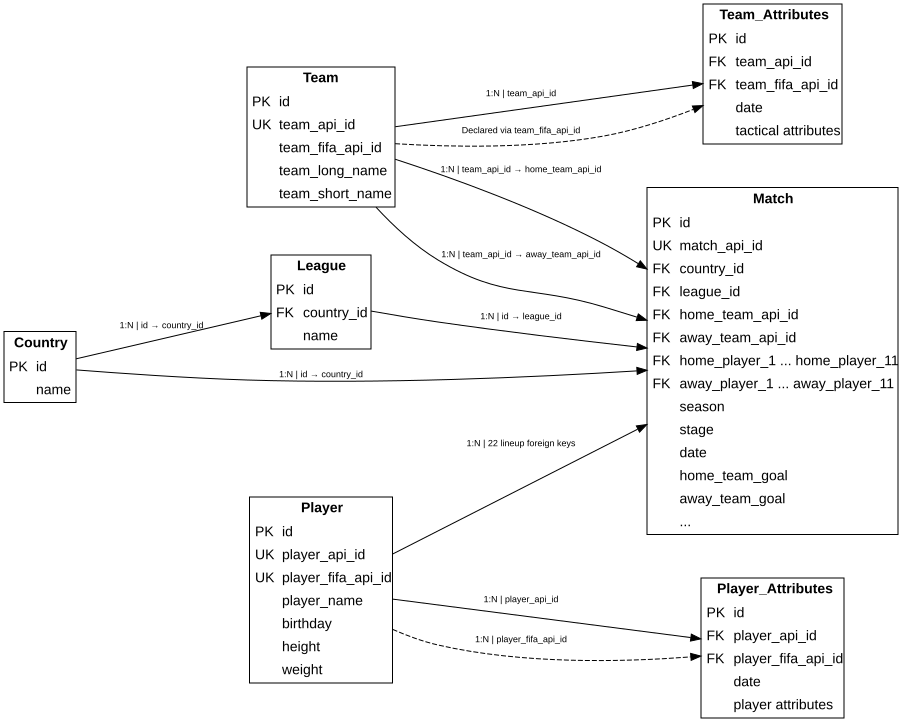

In [62]:
erd = Digraph(
    name="European_Soccer_Source_ERD",
    format="svg",
)

erd.attr(
    rankdir="LR",
    graph_attr="",
)

erd.attr(
    "graph",
    ranksep="1.2",
    nodesep="0.6",
)

erd.attr(
    "node",
    shape="plain",
    fontname="Arial",
)

erd.attr(
    "edge",
    fontname="Arial",
    fontsize="9",
)

for table_name, columns in erd_tables.items():
    erd.node(
        table_name,
        label=build_table_label(
            table_name,
            columns,
        ),
    )

for relationship in erd_relationships:
    erd.edge(
        relationship["parent"],
        relationship["child"],
        label=relationship["label"],
        style=relationship["style"],
    )

output_directory = Path("../reports/figures")
output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

output_path = output_directory / "source_database_erd"

rendered_path = erd.render(
    filename=str(output_path),
    cleanup=True,
)

display(
    SVG(filename=rendered_path)
)

**Nhận xét**

ERD cho thấy `Match` là bảng trung tâm, liên kết với `Country`, `League`, `Team` và `Player`.

Các relationship chính gồm:

* `Country 1:N League`;
* `Country 1:N Match`;
* `League 1:N Match`;
* `Team 1:N Match` theo hai vai trò đội nhà và đội khách;
* `Team 1:N Team_Attributes`;
* `Player 1:N Player_Attributes`;
* `Player 1:N Match` thông qua 22 cột đội hình.

Hai bảng `Team_Attributes` và `Player_Attributes` lưu dữ liệu thuộc tính theo thời gian, nên một đội hoặc cầu thủ có thể xuất hiện trong nhiều bản ghi.

Các relationship sử dụng `team_api_id` và `player_api_id` được thể hiện bằng nét liền vì có key hợp lệ và không phát hiện orphan key. Các relationship sử dụng FIFA identifier được thể hiện bằng nét đứt để cảnh báo vấn đề dữ liệu:

* `Team.team_fifa_api_id` có `NULL` và duplicate;
* `Player_Attributes.player_fifa_api_id` có 49 dòng orphan.

Relationship giữa `Player` và `Match` trong sơ đồ là dạng tổng hợp. Trên thực tế, bảng `Match` chứa 22 foreign key riêng biệt từ `home_player_1` đến `away_player_11`.

Nhìn chung, ERD phản ánh tốt database nguồn, nhưng chưa phải analytical schema cuối cùng cho Power BI. Bảng `Match` có cấu trúc rộng và một số relationship sử dụng FIFA identifier không phù hợp để đưa trực tiếp vào data model.


## 12. Kết luận

Database nguồn đã được khảo sát về cấu trúc, quy mô, `grain`, key, relationship, cardinality, functional dependency và các dạng chuẩn.

Kết quả cho thấy dữ liệu có cấu trúc quan hệ rõ ràng, trong đó `Match` là bảng trung tâm. Một số vấn đề cần lưu ý gồm repeating groups trong `Match`, identifier chưa nhất quán trong dữ liệu cầu thủ và các dependency gây dư thừa ở `Match` và `Team_Attributes`.

Phạm vi phân tích chính sẽ tập trung vào `Country`, `League`, `Match`, `Team` và `Team_Attributes`.

Giai đoạn tiếp theo sẽ thực hiện EDA để kiểm tra missing values, duplicate, giá trị bất thường, phạm vi thời gian và mức độ phù hợp của dữ liệu đối với các câu hỏi phân tích.


In [65]:
connection.close()
print("SQLite connection closed.")

SQLite connection closed.
